In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import scipy.signal as sg
import wavio
import matplotlib.ticker as ticker

In [15]:
def plotSignalTime(signal, title="Signal"):
    plt.figure()
    plt.plot(signal)
    plt.title(title)
    plt.ylabel('Amplitude')
    plt.xlabel('sample index')
    plt.grid(True)
    fig = plt.gcf()
    fig.set_size_inches(16, 5)
    

In [25]:
def plotAmplFreqResp(signal, Fs, use_log_scale=False, use_grid=True):   
    plt.figure()
    
    fft_signal = np.fft.fft(signal)
    fft_signal = np.fft.fftshift(fft_signal)
    freqs = np.linspace(-Fs/2, Fs/2, len(fft_signal))
    
    if use_log_scale:
        plt.plot(freqs, 20*np.log10(np.abs(fft_signal) + 1e-12)) # +epsilon to avoid log(0)
        plt.ylabel('Amplitude, dB')
    else:
        plt.plot(freqs, np.abs(fft_signal))
        plt.ylabel('Amplitude')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)
    
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on() 
        plt.grid(which='major', linewidth=2)
        plt.grid(which='minor', linestyle=':')
    
    fig = plt.gcf()
    fig.set_size_inches(16, 5)

In [26]:
def plotPhaseFreqResp(fft_signal, Fs, use_grid=True):
    fft_signal = np.fft.fft(fft_signal) # make FFT of info signal
    fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
    
    plt.figure()
    
    plt.plot(np.linspace(-Fs/2, Fs/2, len(fft_signal)), np.angle(fft_signal))
    plt.ylabel('Phase')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)
    
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on()
        plt.grid(which='major', linewidth=2)
        plt.grid(which='minor', linestyle=':')
    
    fig = plt.gcf()
    fig.set_size_inches(16, 5)

# HW10*: Make Frequency modulation example (+0.5) #

Cлайд 19: z_FM(t) = A * cos(w_c*t + w_d * integral(s_m(t)))

Используем np.cumsum для интеграла

In [27]:
def modulateFM(info_signal, f_c, f_dev, Fs, t=None):
    if t is None:
        t = np.arange(len(info_signal)) / Fs
    
    # Интегрируем сигнал (накопленная фаза)
    # Делим на Fs, так как dt = 1/Fs
    phase_integral = np.cumsum(info_signal) / Fs
    
    fm_signal = np.cos(2 * np.pi * f_c * t + 2 * np.pi * f_dev * phase_integral)
    return fm_signal

In [34]:
Fs_ex = 100000  # Гц
duration = 1 # секунда
t_ex = np.linspace(0, duration, int(Fs_ex * duration))

f_m = 3
info_ex = np.cos(2 * np.pi * f_m * t_ex)

f_c_ex = 50 # несущая
f_dev_ex = 1 # девиация частоты

fm_signal_ex = modulateFM(info_ex, f_c_ex, f_dev_ex, Fs_ex, t_ex)

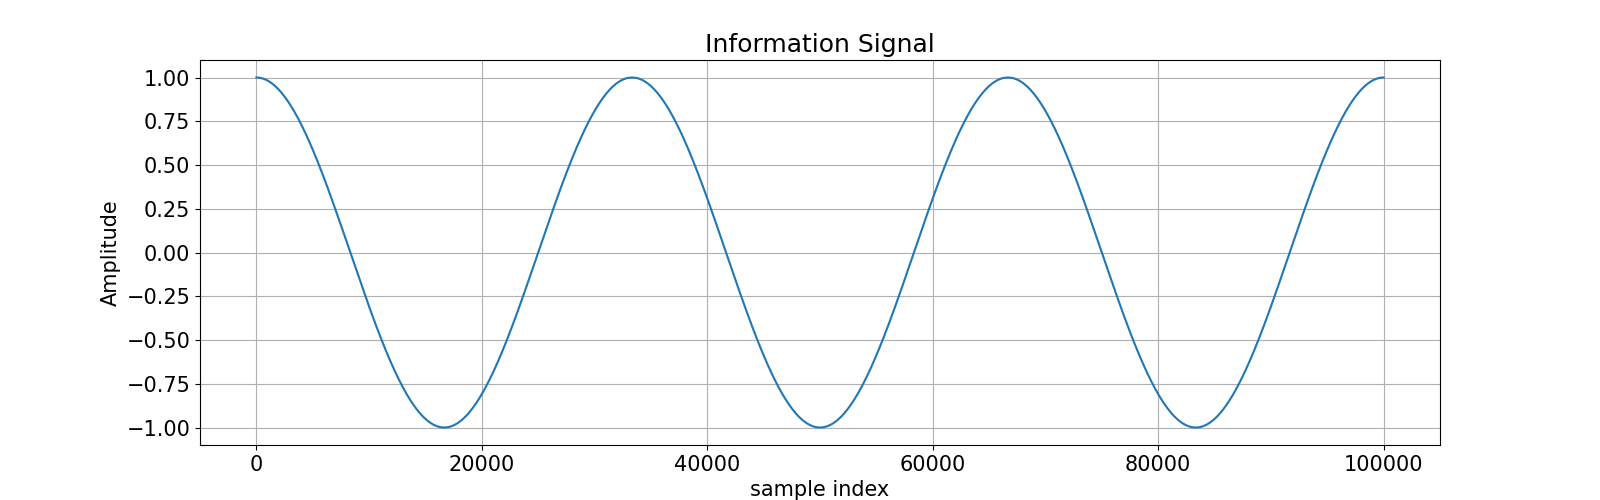

In [35]:
plotSignalTime(info_ex, "Information Signal")

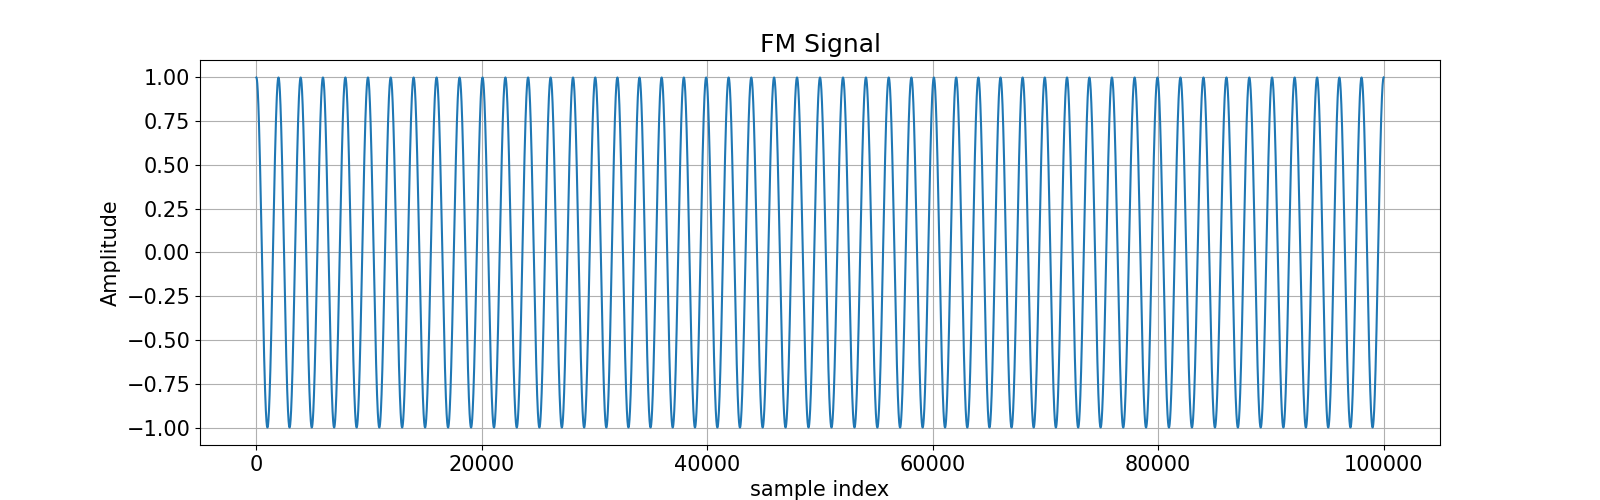

In [36]:
plotSignalTime(fm_signal_ex, "FM Signal")

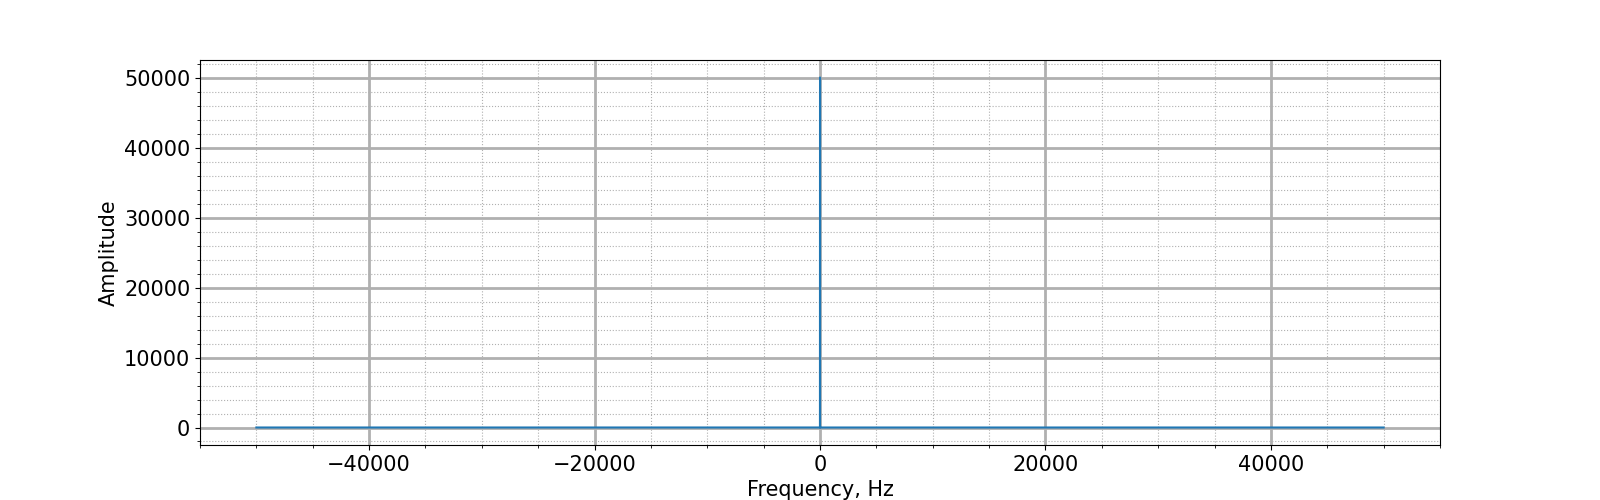

In [37]:
plotAmplFreqResp(info_ex, Fs_ex)

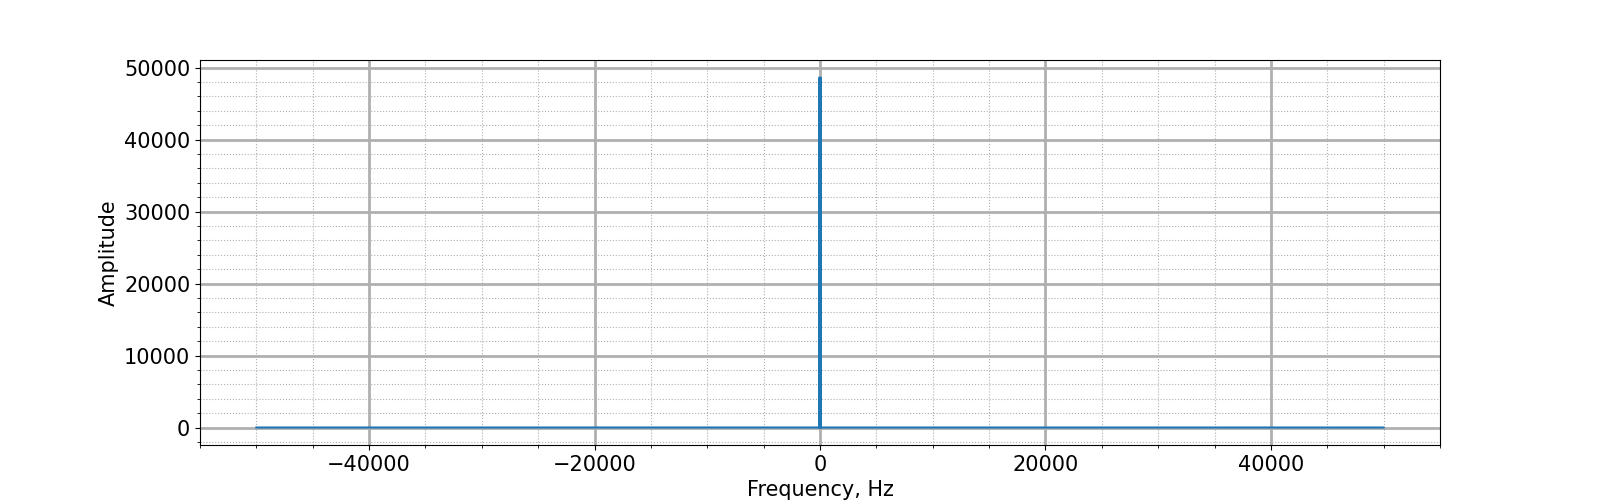

In [38]:
plotAmplFreqResp(fm_signal_ex, Fs_ex)

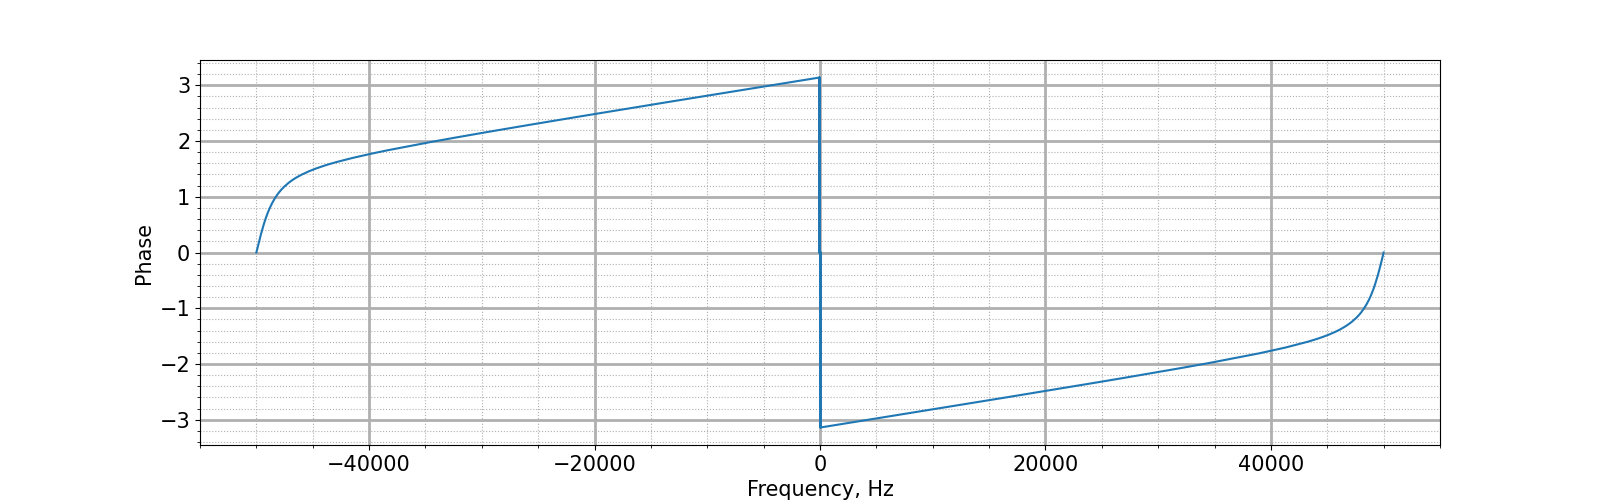

In [39]:
plotPhaseFreqResp(fm_signal_ex, Fs_ex)

# HW11: Modulate sound using FM #

In [40]:
# Read audio data from file 
info_signal_orig, Fs = sf.read('sounds/my_citation_.wav')

print("Number of samples: ", len(info_signal_orig), ", sampling frequency:", Fs)

Number of samples:  978025 , sampling frequency: 48000


In [163]:
duration = len(info_signal_orig) / Fs
print(duration)

20.375520833333333


In [164]:
info_signal_orig = info_signal_orig[:, 0]

# Cut a portion of signal if needed 
do_cut = False

signal_start = 40000 #samples
signal_len = 80000 #samples

if do_cut:
    signal_duration = signal_len / Fs #seconds
    info_signal = info_signal_orig[signal_start:(signal_start+signal_len)] # get "info signal" as part of input signal 
else:
    signal_duration = len(info_signal_orig) / Fs #seconds
    info_signal = info_signal_orig # get "info signal" = input signal 

In [165]:
len(info_signal_orig)

978025

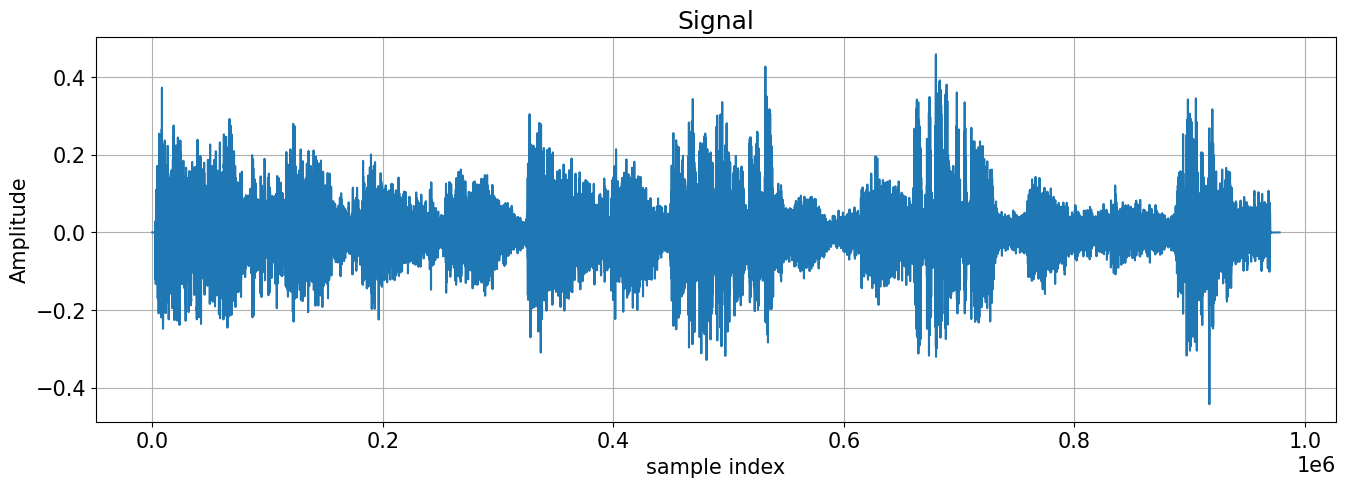

In [166]:
plotSignalTime(info_signal)

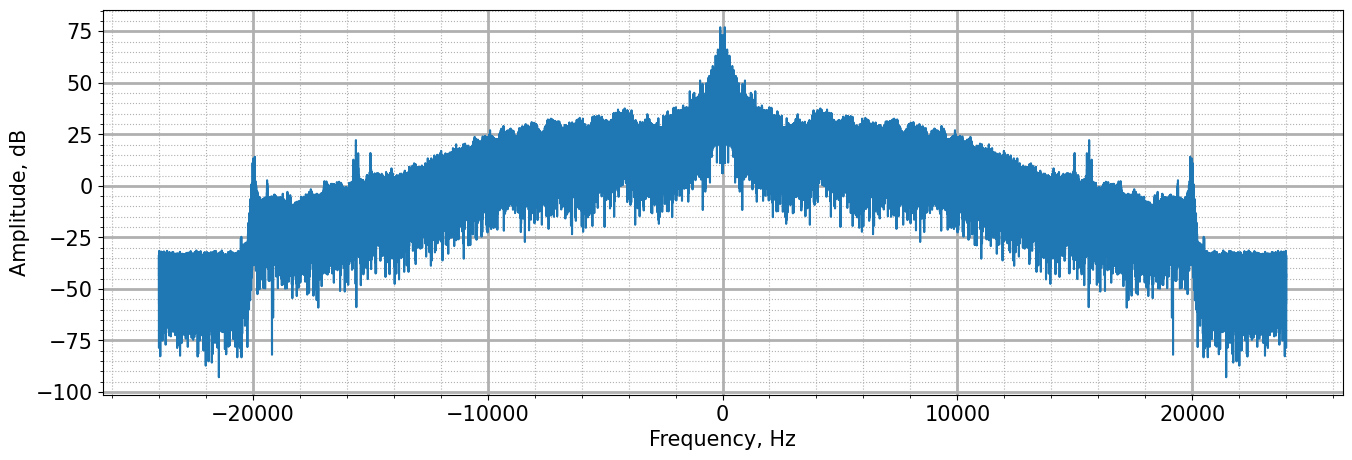

In [167]:
plotAmplFreqResp(info_signal, Fs, True)

In [168]:
f_c = Fs / 4
f_dev = f_c / 20

bandwith_half = f_dev + 10000

In [169]:
bandwith_half

10600.0

In [170]:
# Build a Low Pass Filter before modulation 
lpf = sg.iirdesign(10000, 10600, 0.001, 100, fs=Fs)

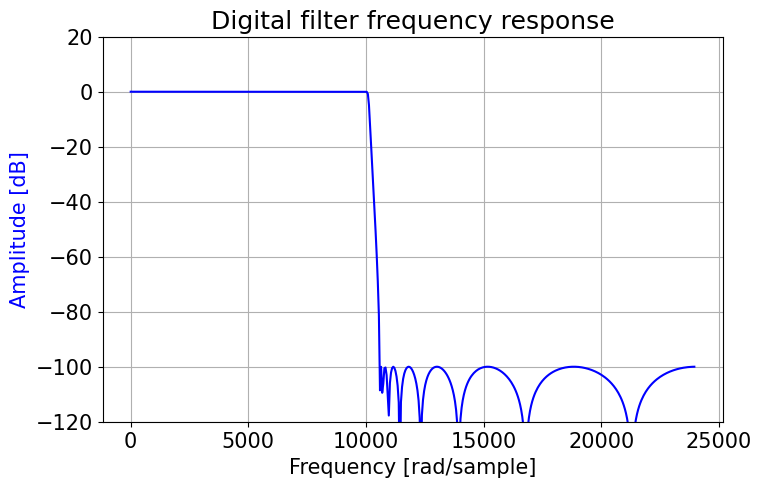

In [171]:
w, h = sg.freqz(*lpf, fs=Fs)

fig, ax1 = plt.subplots()
ax1.set_title('Digital filter frequency response')
ax1.plot(w, 20 * np.log10(abs(h)), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [rad/sample]')
ax1.grid(True)
ax1.set_ylim([-120, 20])
nticks = 8
ax1.yaxis.set_major_locator(ticker.LinearLocator(nticks))
 
fig = plt.gcf()
fig.set_size_inches(8, 5) 

In [172]:
# Apply Low Pass Filter before modulation 
filtered_info_signal = sg.lfilter(*lpf, info_signal)

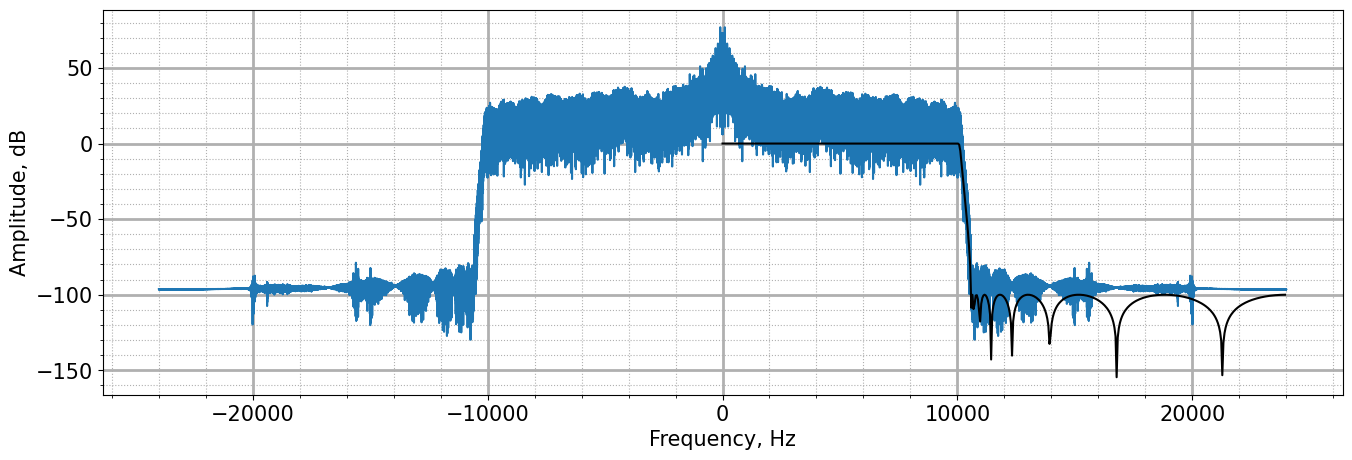

In [173]:
plotAmplFreqResp(filtered_info_signal, Fs, True)
plt.plot(w, 20 * np.log10(abs(h)), 'k')

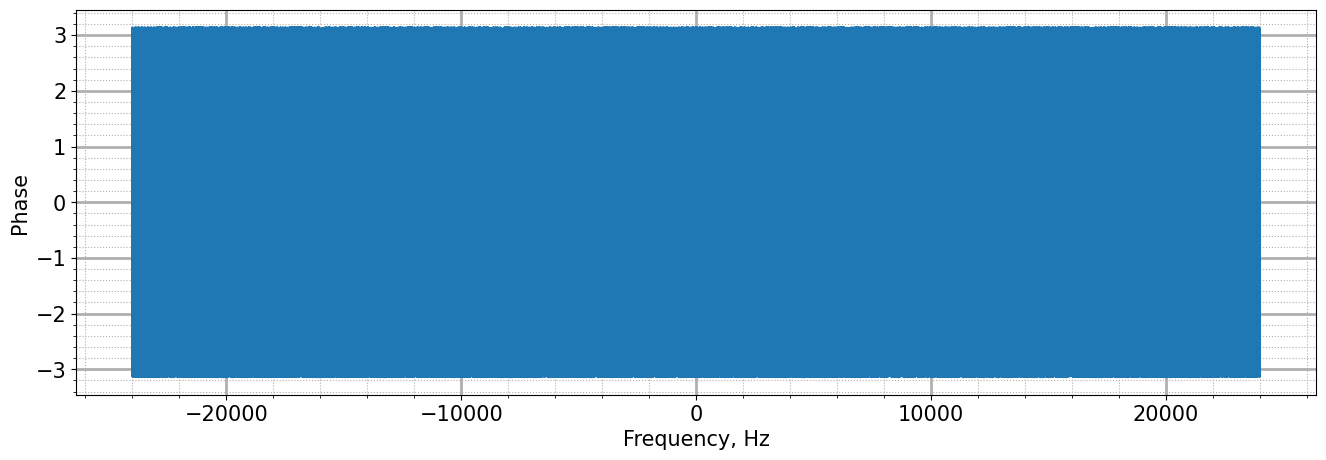

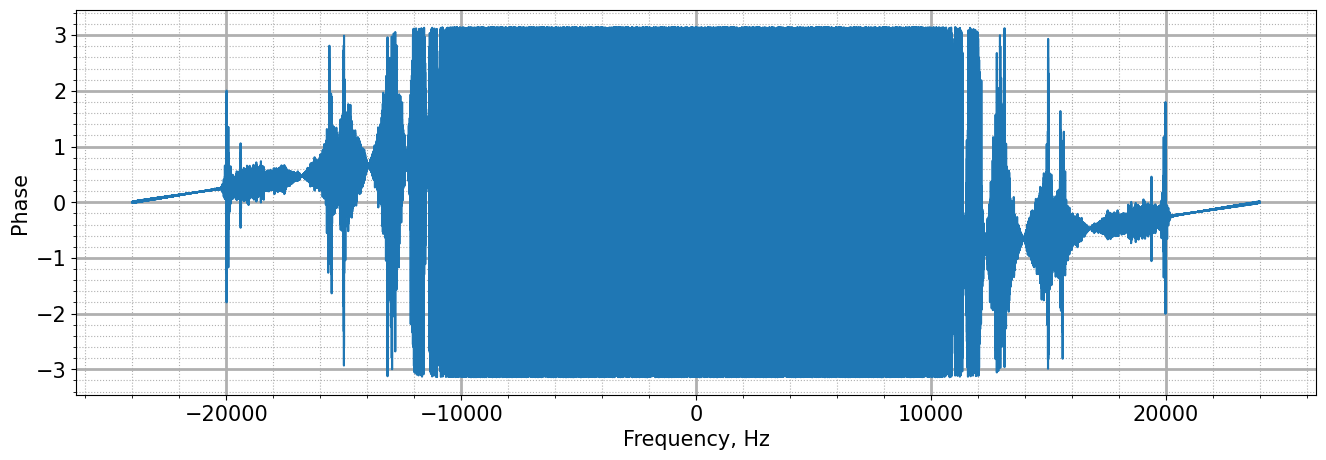

In [174]:
plotPhaseFreqResp(info_signal, Fs)
plotPhaseFreqResp(filtered_info_signal, Fs)
# plt.plot(w, 20 * np.log10(abs(h)), 'k')

In [175]:
filtered_info_signal = filtered_info_signal / np.max(np.abs(filtered_info_signal))

sf.write("sounds/my_filtered_citation_fm.wav", filtered_info_signal, Fs)

In [176]:
t = np.linspace(0, duration, len(filtered_info_signal))

fm_audio = modulateFM(filtered_info_signal, f_c, f_dev, Fs, t)

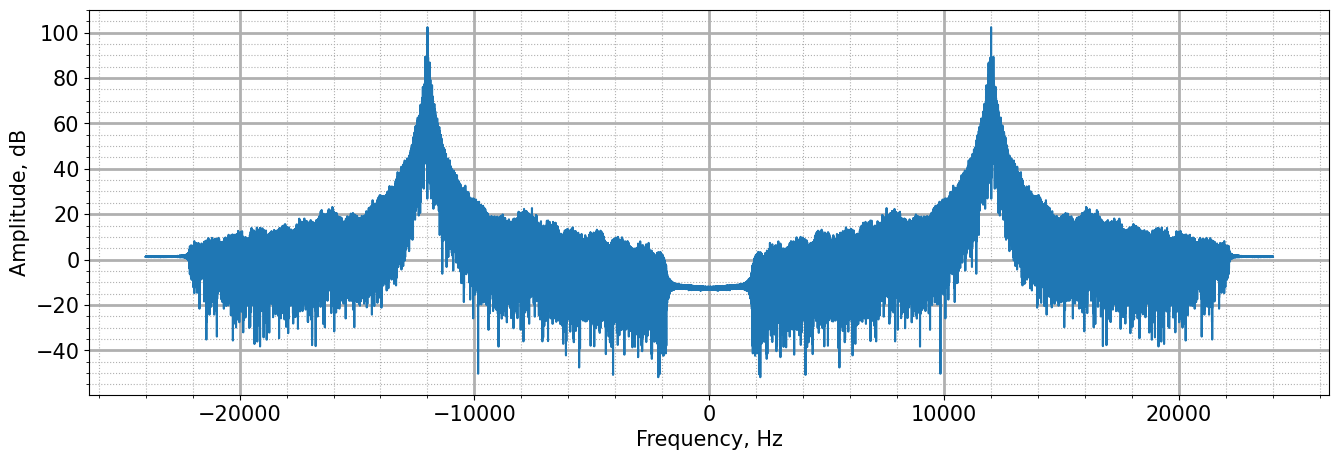

In [177]:
plotAmplFreqResp(fm_audio, Fs, True)

In [178]:
fm_audio = fm_audio / np.max(np.abs(fm_audio))

sf.write("sounds/fm_audio_my.wav", fm_audio, Fs)

# HW12: Demodulate FM signal #

In [179]:
# Reading AM-modulated signal from file 
fm_samples, Fs = sf.read('sounds/fm_audio_my.wav')

In [180]:
# Simulate channel noise 
noise = np.random.normal(0, 0.001, len(fm_samples)) 
fm_signal_recorded = fm_samples + noise

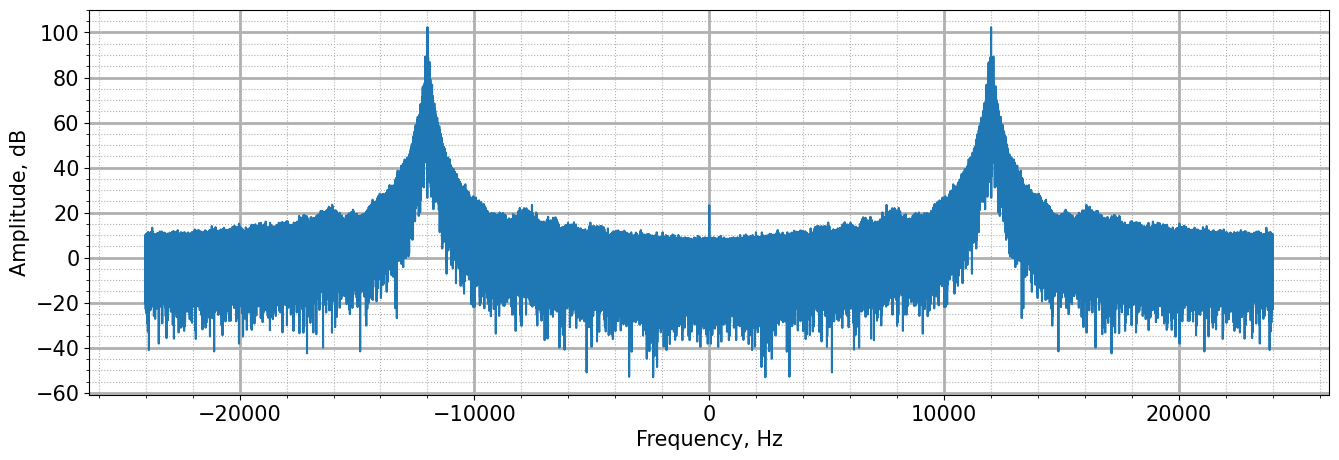

In [181]:
plotAmplFreqResp(fm_signal_recorded, Fs, True, True)

In [182]:
bpf = sg.iirdesign(wp=[(f_c - bandwith_half)/(Fs/2), (f_c + bandwith_half)/(Fs/2)], 
                   ws=[(f_c - bandwith_half - 500)/(Fs/2), (f_c + bandwith_half + 500)/(Fs/2)], 
                   gpass=0.01, gstop=100)

# Фильтруем зашумленный сигнал ДО демодуляции
fm_signal_clean = sg.lfilter(*bpf, fm_signal_recorded)

Буду восстанавливать при помощи сдвига несущей + взятие угла у комплексной огибающей

In [183]:
restored_signal = fm_signal_clean * np.exp(-1j * 2 * np.pi * f_c * t)

In [184]:
# Убираем накопленные шумы
lpf_baseband = sg.iirdesign(10000, 10600, 0.001, 100, fs=Fs)

filtered_signal = sg.lfilter(*lpf_baseband, restored_signal)

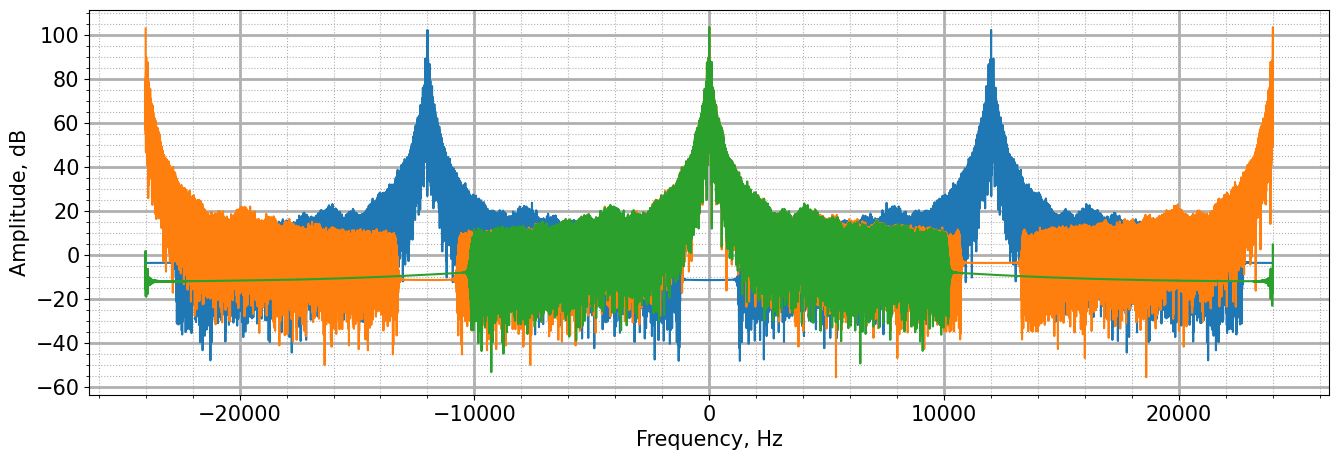

In [185]:
plotAmplFreqResp(fm_signal_clean, Fs, True, True)
plotAmplFreqResp(restored_signal, Fs, True)
plotAmplFreqResp(filtered_signal, Fs, True)

In [186]:
instantaneous_phase = np.unwrap(np.angle(filtered_signal))

instantaneous_frequency = np.diff(instantaneous_phase) * Fs / (2.0 * np.pi * f_dev)
instantaneous_frequency = np.append(instantaneous_frequency, instantaneous_frequency[-1]) # Возвращаем размер массива до прежнего, дублируя последний элемент

result_filtered_signal = instantaneous_frequency - np.mean(instantaneous_frequency)

# Прогоним еще раз через ФНЧ для идеальной гладкости
result_filtered_signal = sg.lfilter(*lpf_baseband, result_filtered_signal)

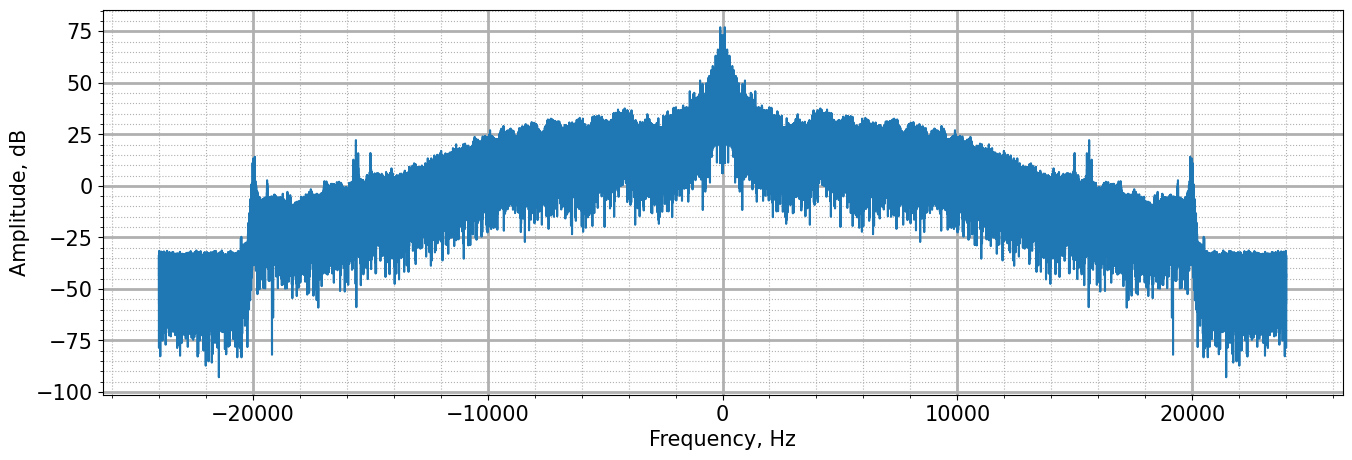

In [187]:
plotAmplFreqResp(info_signal, Fs, True)

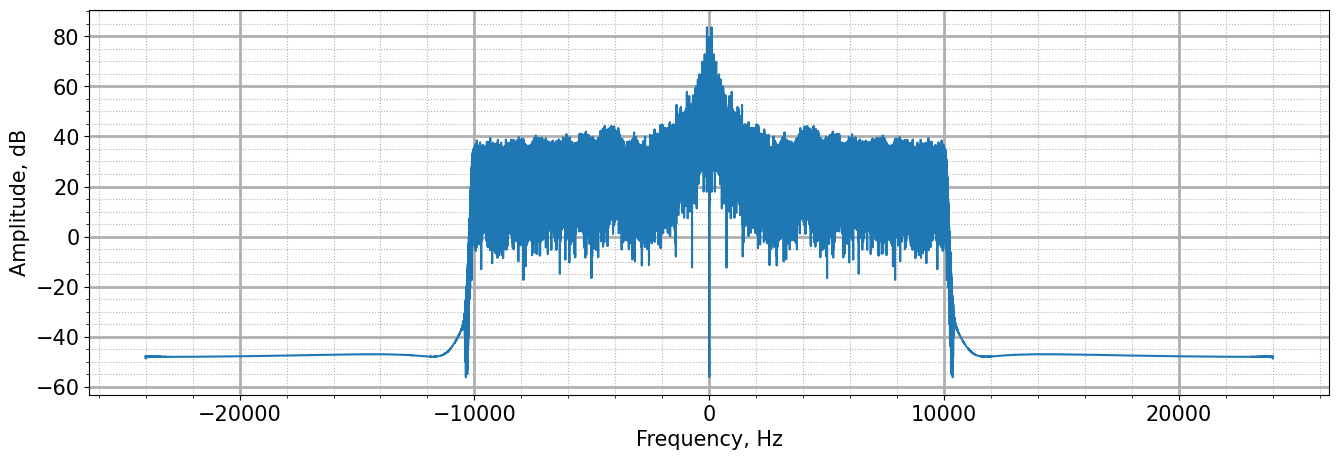

In [188]:
plotAmplFreqResp(result_filtered_signal, Fs, True)

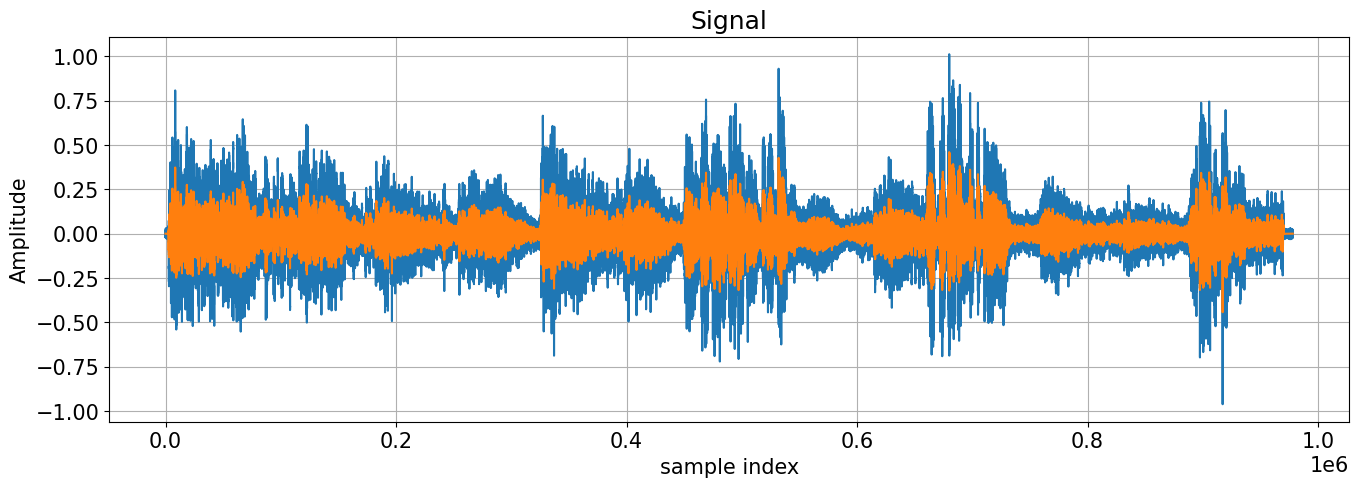

In [189]:
plotSignalTime(result_filtered_signal)
plotSignalTime(info_signal)

In [190]:
# Write resulting audio to audio file 
norm_filtered_signal = result_filtered_signal/max(np.abs(result_filtered_signal))

wavio.write("sounds/my_result_fm_T.wav", norm_filtered_signal, Fs, sampwidth=2)

# HW13*: Demodulate secret FM signal (+0.5) #

Предлагаю в качестве секрета создать реверснутый сигнал на нестандартной частоте

In [191]:
secret_info = filtered_info_signal[::-1] # Reverse

f_c_secret = Fs / 5
f_dev_secret = f_c_secret / 50

lpf_secret = sg.iirdesign(f_c_secret - 1000 - f_dev_secret, f_c_secret - f_dev_secret - 500, 0.01, 100, fs=Fs)
secret_info = sg.lfilter(*lpf_secret, secret_info)

In [192]:
t_sec = np.arange(len(secret_info)) / Fs
secret_fm_signal = modulateFM(secret_info, f_c_secret, f_dev_secret, Fs, t_sec)

noise_secret = np.random.normal(0, 0.001, len(secret_fm_signal))
secret_fm_signal_noised = secret_fm_signal #+ noise_secret

sf.write("sounds/my_secret_fm.wav", secret_fm_signal_noised, Fs)

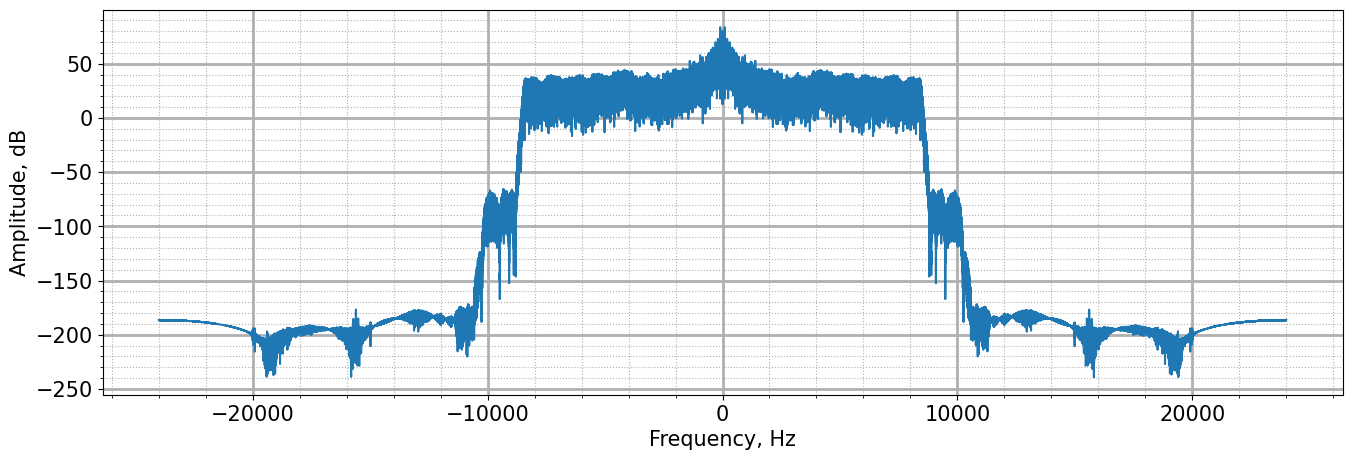

In [193]:
plotAmplFreqResp(secret_info, Fs, True)

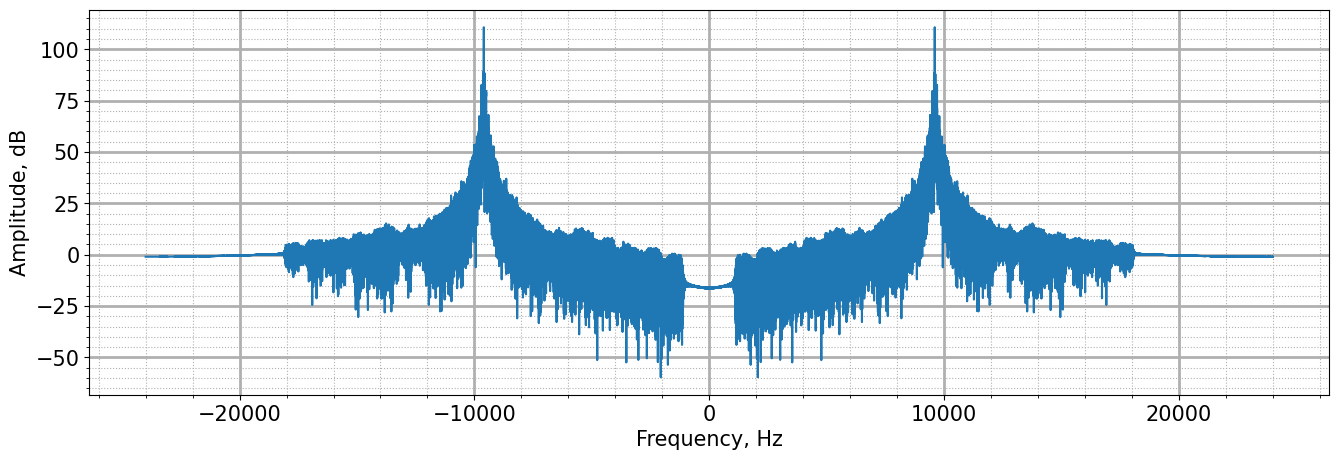

In [194]:
plotAmplFreqResp(secret_fm_signal, Fs, True)

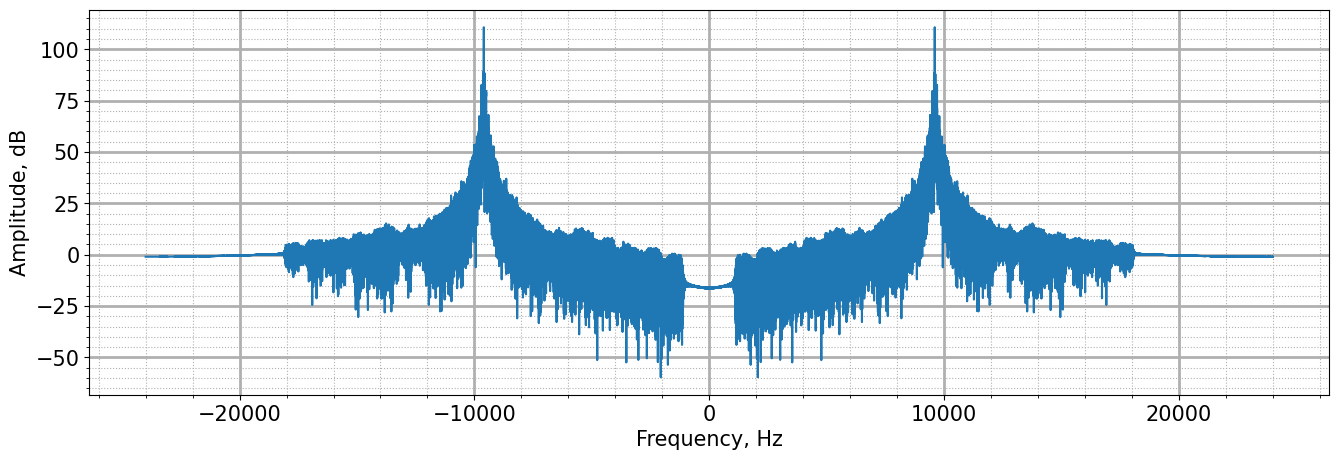

In [195]:
plotAmplFreqResp(secret_fm_signal_noised, Fs, True)

Демодуляция

In [196]:
fm_signal_recorded_sec, Fs = sf.read('sounds/my_secret_fm.wav')

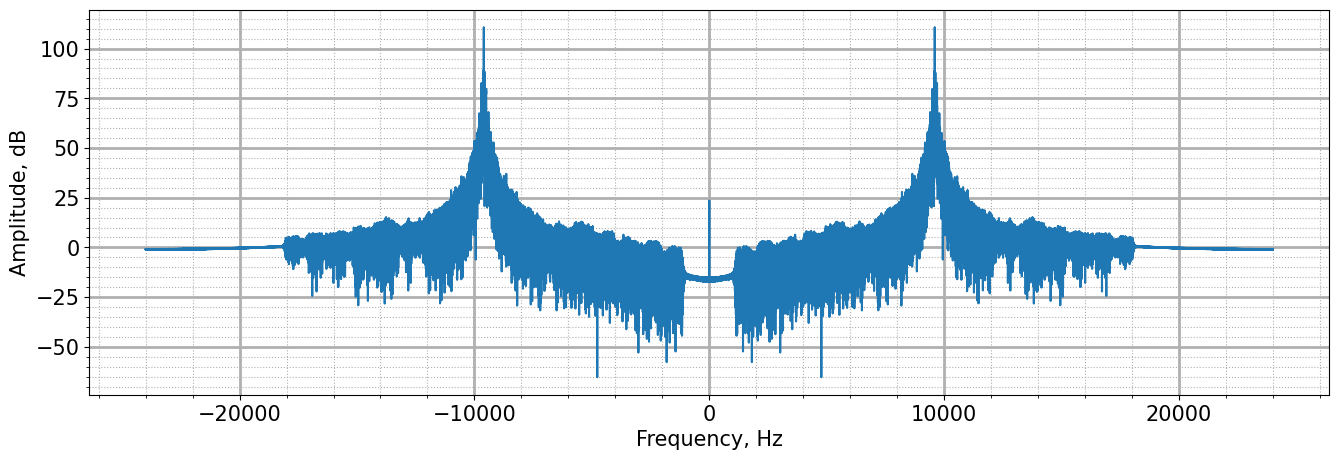

In [197]:
plotAmplFreqResp(fm_signal_recorded_sec, Fs, use_log_scale=True)

Надо понять частоту несущей. В спектре находим пик (на какой частоте), используем argmax

In [198]:
fft_signal_sec = np.fft.fft(fm_signal_recorded_sec) 
fft_signal_sec = np.fft.fftshift(fft_signal_sec) 

freqs_sec = np.linspace(-Fs/2, Fs/2, len(fft_signal_sec))

f_c_found = np.abs(freqs_sec[np.argmax(fft_signal_sec)])

print(f_c_found)

9600.009815710044


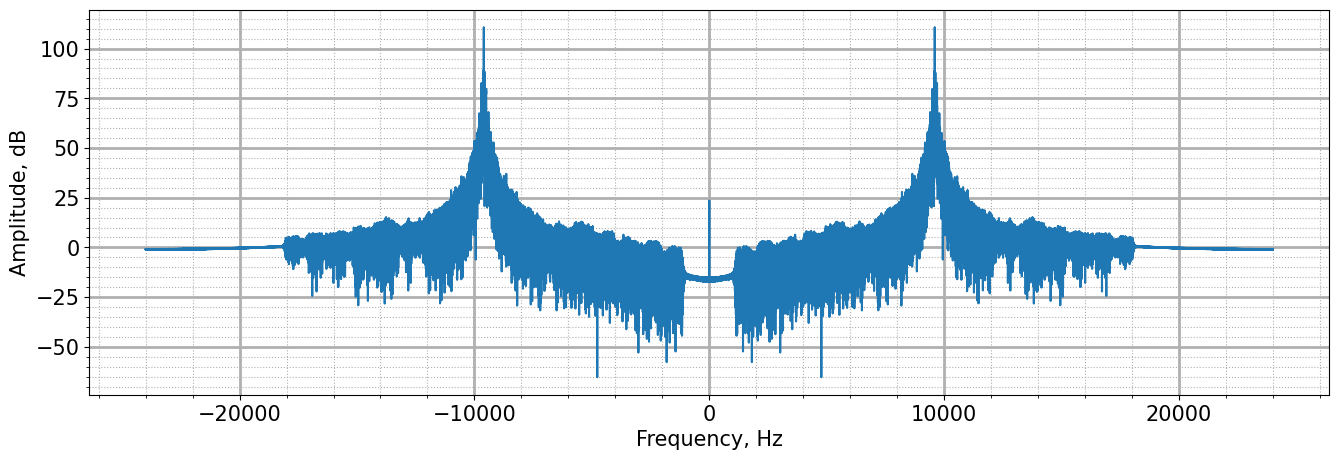

In [199]:
plotAmplFreqResp(fm_signal_recorded_sec, Fs, True, True)

In [200]:
fm_signal_clean_sec = fm_signal_recorded_sec

Буду восстанавливать при помощи сдвига несущей + взятие угла у комплексной огибающей

In [201]:
restored_signal_sec = fm_signal_clean_sec * np.exp(-1j * 2 * np.pi * f_c_found * t_sec)

lpf_baseband_sec = sg.iirdesign(f_c_found - 1000 - f_dev_secret, f_c_found - f_dev_secret - 500, 0.001, 100, fs=Fs)

filtered_signal_sec = sg.lfilter(*lpf_baseband_sec, restored_signal_sec)

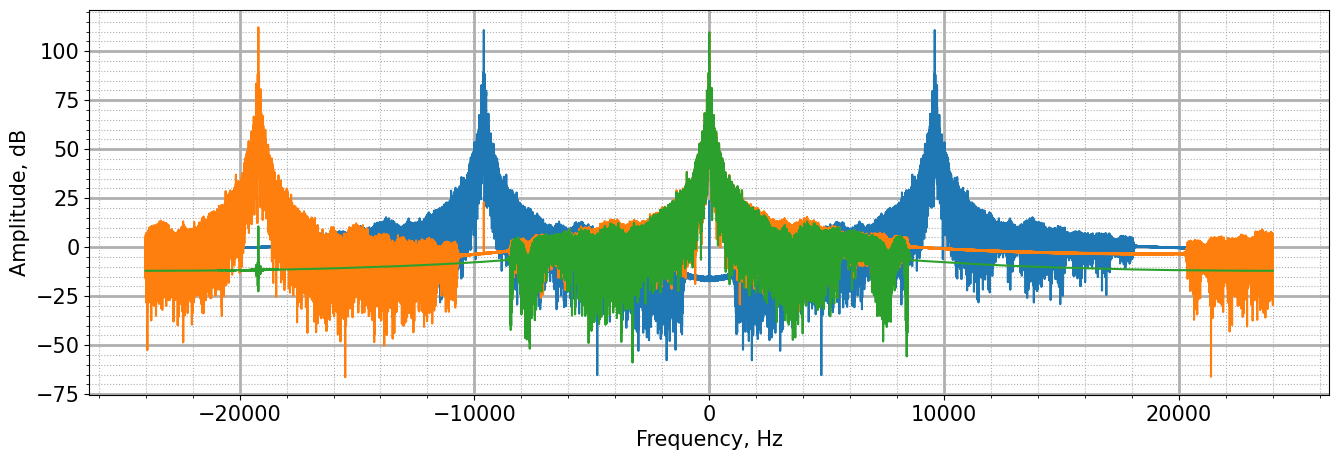

In [202]:
plotAmplFreqResp(fm_signal_clean_sec, Fs, True)
plotAmplFreqResp(restored_signal_sec, Fs, True)
plotAmplFreqResp(filtered_signal_sec, Fs, True)

In [203]:
instantaneous_phase_sec = np.unwrap(np.angle(filtered_signal_sec))

instantaneous_frequency_sec = np.diff(instantaneous_phase_sec) * Fs / (2.0 * np.pi * f_dev_secret)
instantaneous_frequency_sec = np.append(instantaneous_frequency_sec, instantaneous_frequency_sec[-1])  # Возвращаем размер массива до прежнего, дублируя последний элемент

result_filtered_signal_sec = instantaneous_frequency_sec - np.mean(instantaneous_frequency_sec)

# Прогоним еще раз через ФНЧ для идеальной гладкости
result_filtered_signal_sec = sg.lfilter(*lpf_baseband_sec, result_filtered_signal_sec)

norm_filtered_signal_sec = result_filtered_signal_sec/max(np.abs(result_filtered_signal_sec))

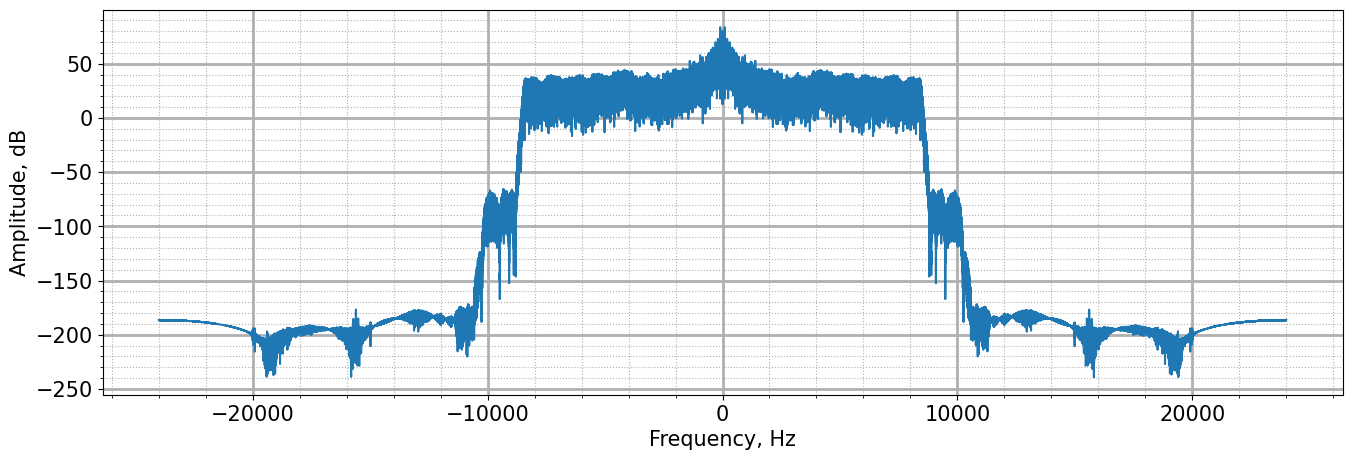

In [204]:
plotAmplFreqResp(secret_info, Fs, True)

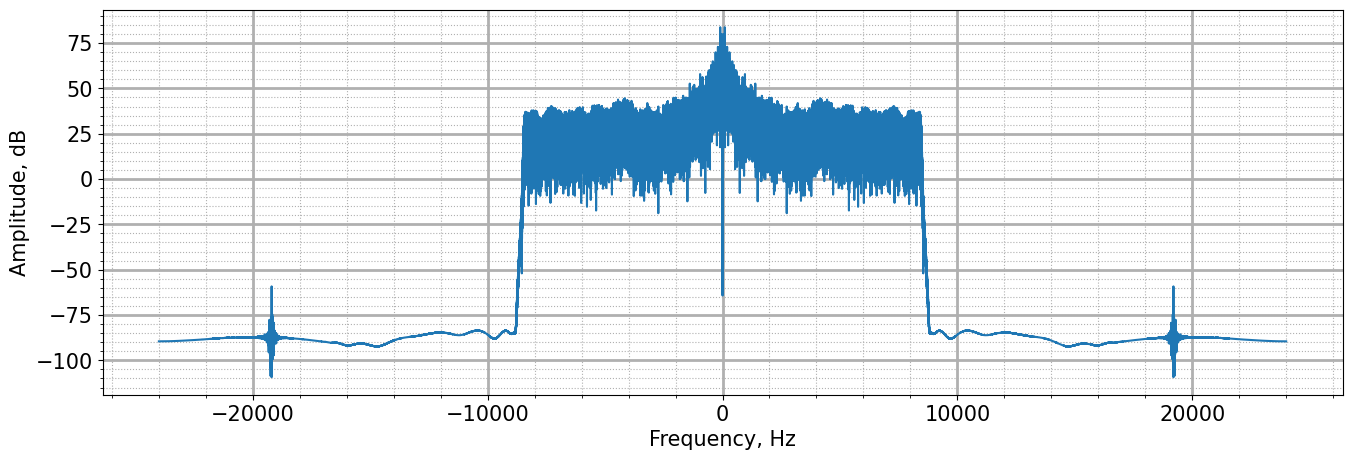

In [205]:
plotAmplFreqResp(norm_filtered_signal_sec, Fs, True)

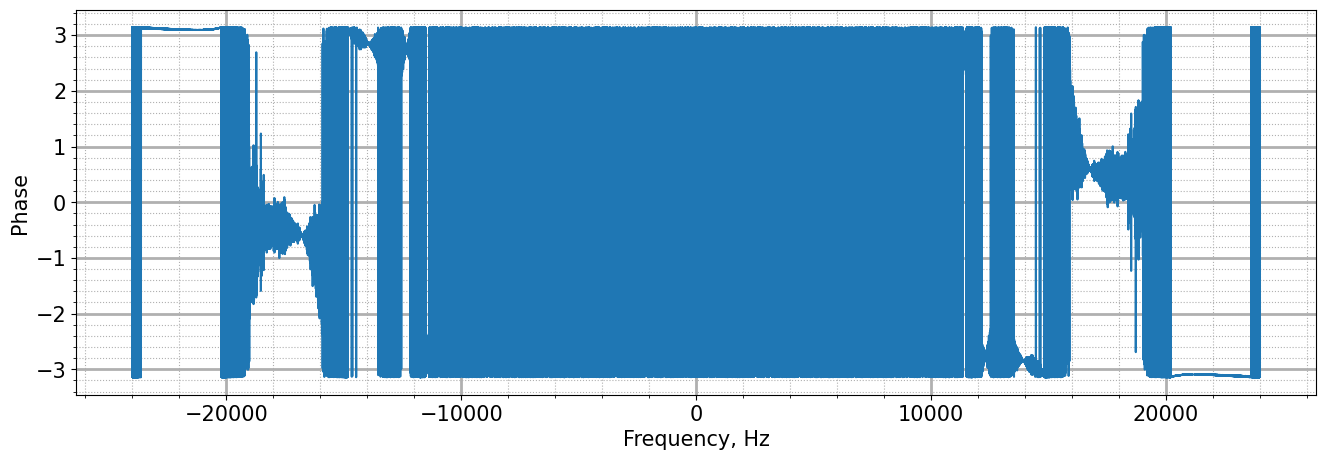

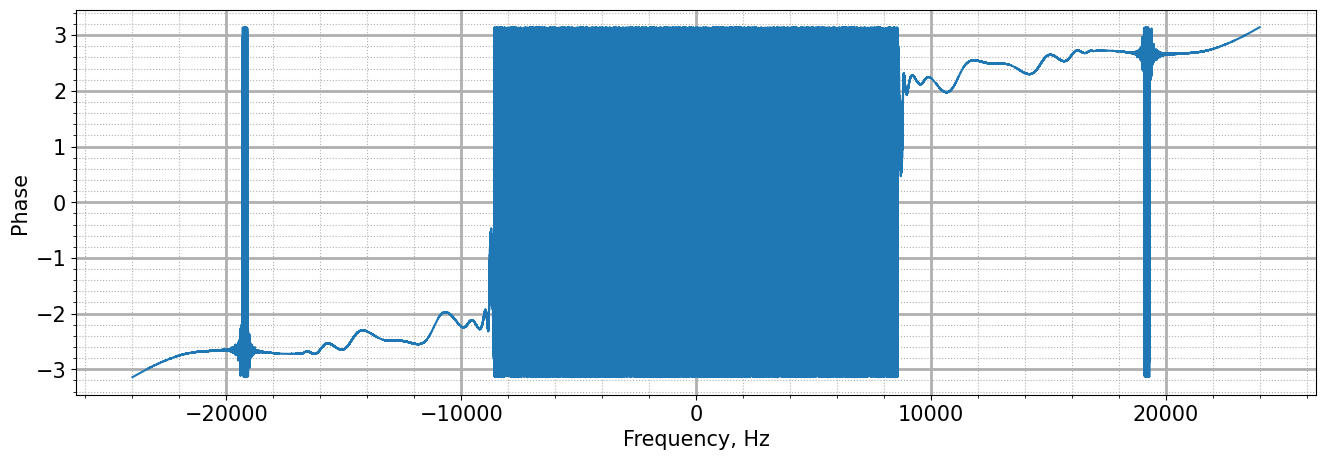

In [206]:
plotPhaseFreqResp(secret_info, Fs)
plotPhaseFreqResp(norm_filtered_signal_sec, Fs)

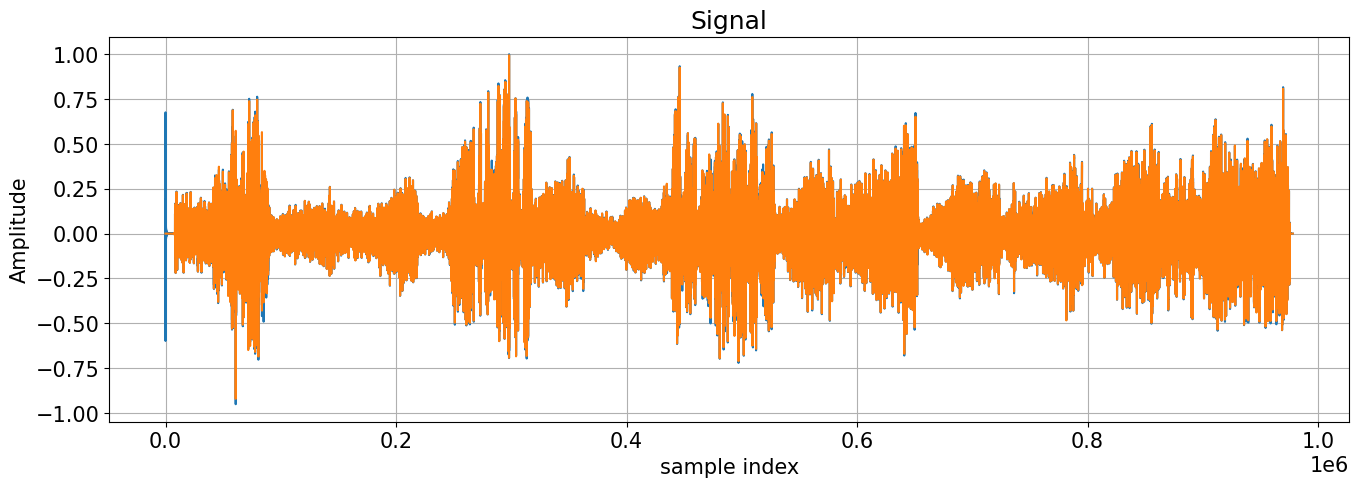

In [207]:
plotSignalTime(norm_filtered_signal_sec)
plotSignalTime(secret_info)

In [208]:
wavio.write("sounds/my_secret_solved.wav", norm_filtered_signal_sec, Fs, sampwidth=2)

# HW14*: Make Phase modulatation (+2) #

Для фазовой модуляции (ФМ/PM) мы используем уже готовый частотный модулятор.
Согласно связи ФМ и ЧМ (Слайд 21), ЧМ интегрирует сигнал, а ФМ — нет.
Поэтому, чтобы получить ФМ сигнал через ЧМ модулятор, необходимо подать на его вход производную информационного сигнала.

In [41]:
def modulatePM(info_signal, f_c, m_idx, Fs, t=None):
    if t is None:
        t = np.arange(len(info_signal)) / Fs
    
    # Берем производную от информационного сигнала
    diff_info = np.diff(info_signal) * Fs
    # Возвращаем размер массива до прежнего, дублируя последний элемент
    diff_info = np.append(diff_info, diff_info[-1])
    
    # f_dev вычисляется из индекса фазовой модуляции m_idx
    # m_idx = 2 * pi * f_dev => f_dev = m_idx / (2 * pi)
    f_dev_pm = m_idx / (2 * np.pi)
    
    pm_signal = modulateFM(diff_info, f_c, f_dev_pm, Fs, t)
    return pm_signal

In [77]:
m_idx_ex = 1 # индекс фазовой модуляции

pm_signal_ex = modulatePM(info_ex, f_c_ex, m_idx_ex, Fs_ex, t_ex)

In [78]:
f_m

3

In [79]:
print(f_c_ex, m_idx_ex, Fs_ex)

50 1 100000


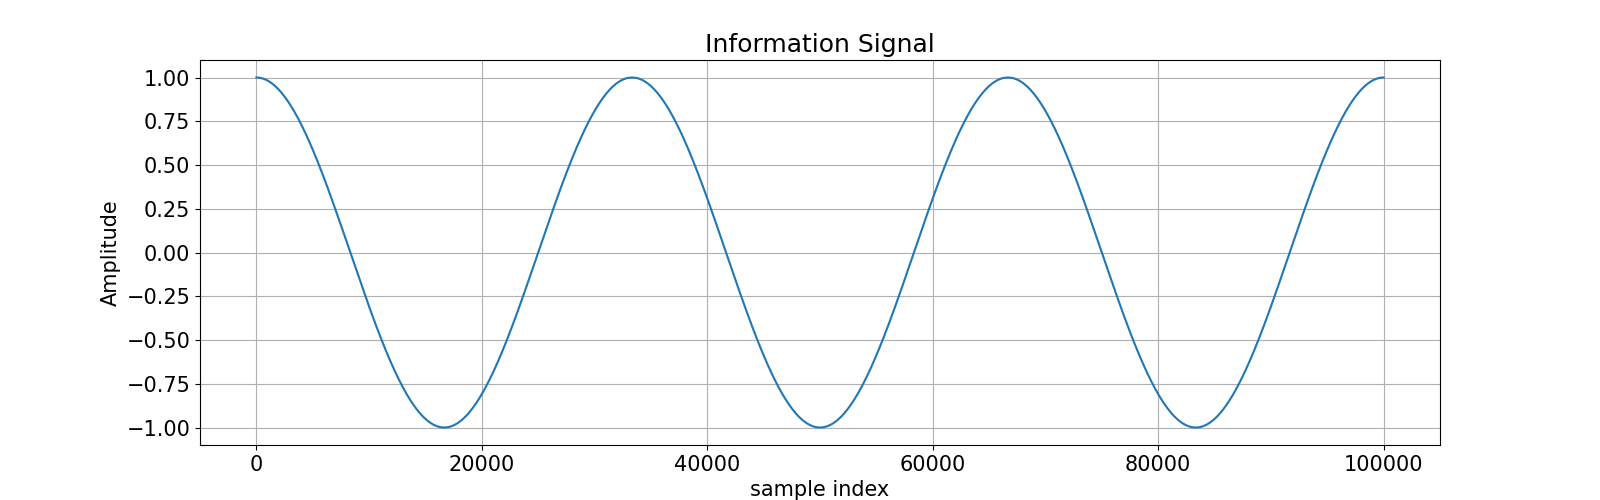

In [80]:
plotSignalTime(info_ex, "Information Signal")

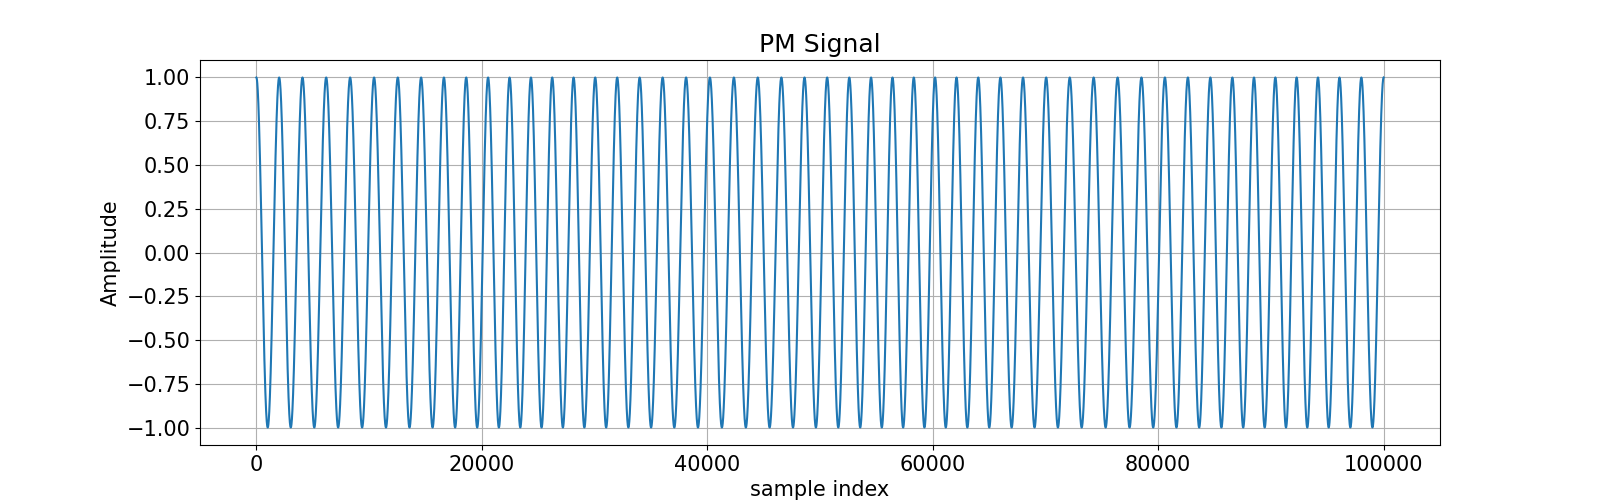

In [81]:
plotSignalTime(pm_signal_ex, "PM Signal")

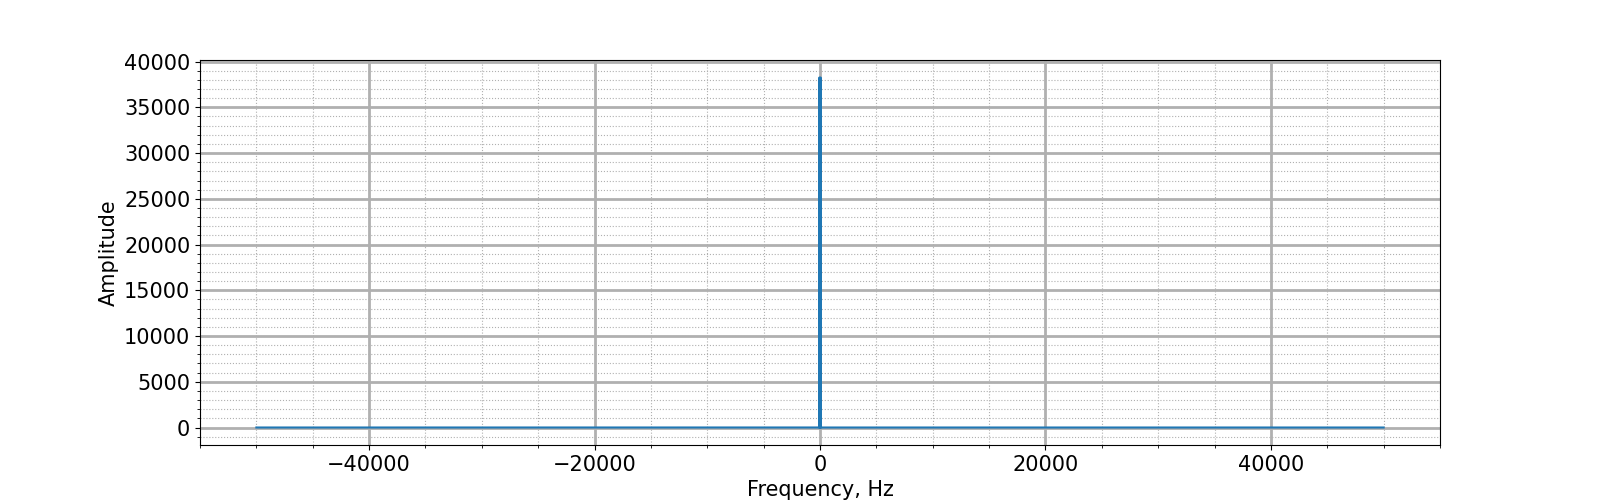

In [82]:
plotAmplFreqResp(pm_signal_ex, Fs_ex)

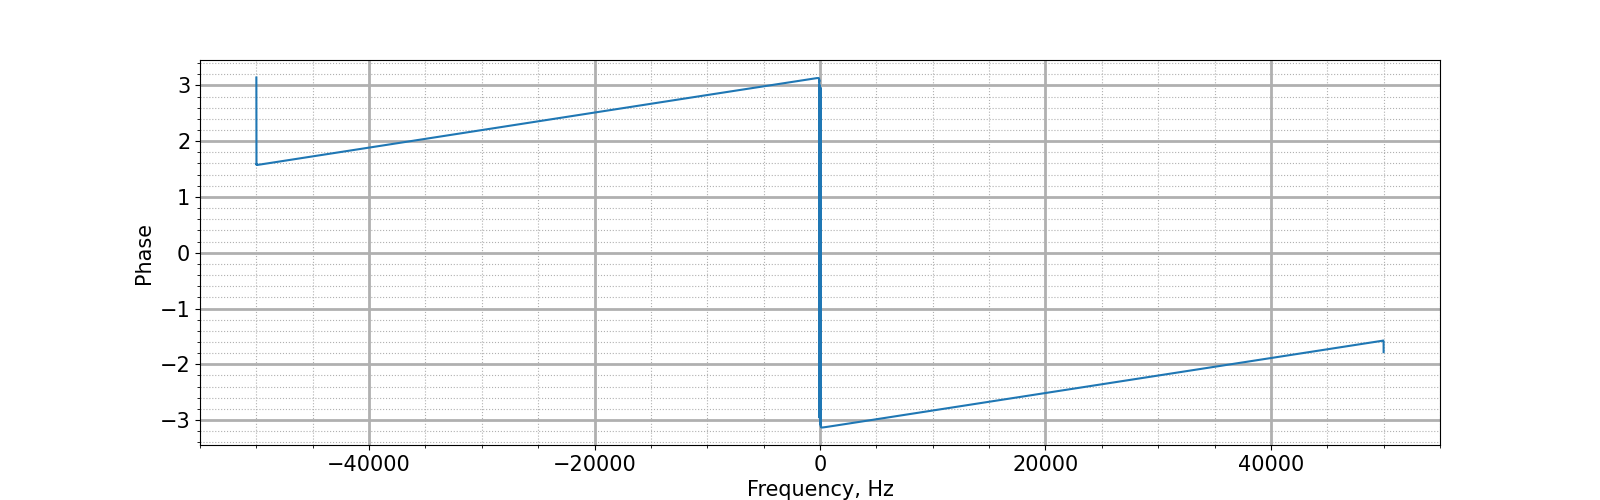

In [83]:
plotPhaseFreqResp(pm_signal_ex, Fs_ex)

# Modulate sound using PM #

In [48]:
f_c_pm = Fs / 4
m_idx_audio = np.pi # Индекс модуляции для аудио

pm_audio = modulatePM(filtered_info_signal, f_c_pm, m_idx_audio, Fs, t)

NameError: name 'filtered_info_signal' is not defined

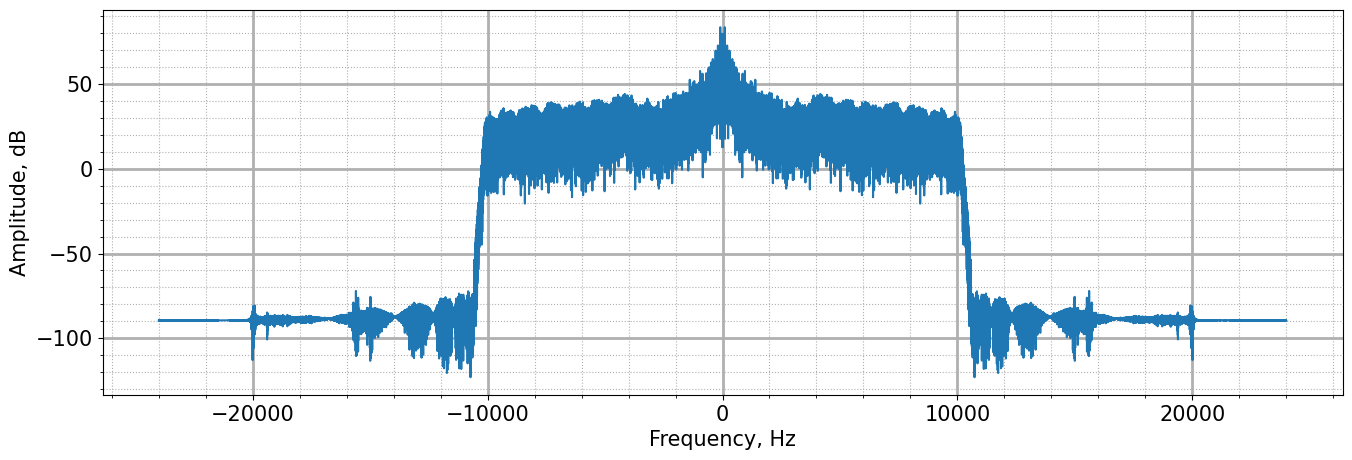

In [217]:
plotAmplFreqResp(filtered_info_signal, Fs, True)

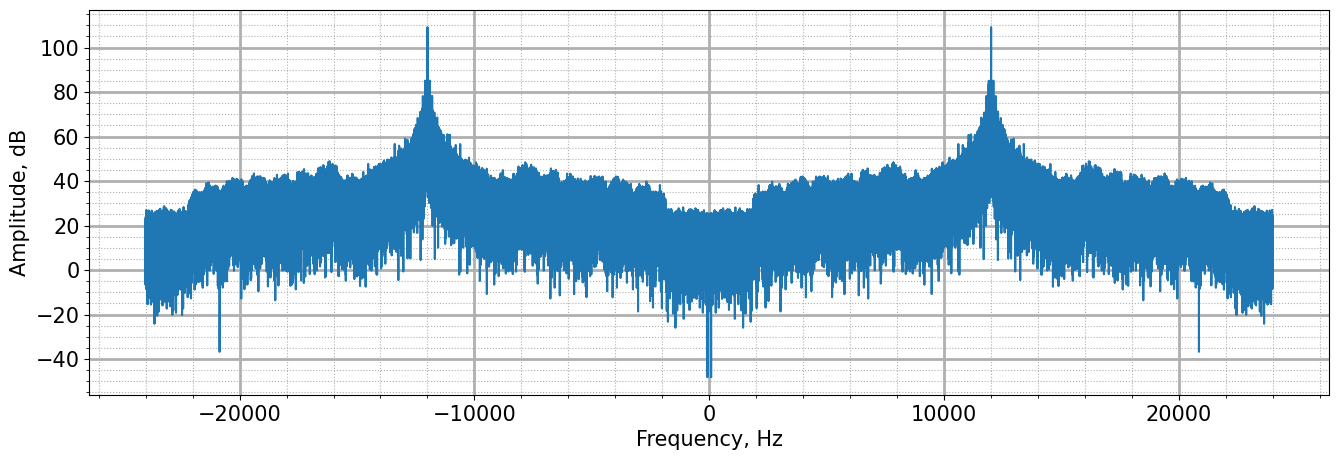

In [218]:
plotAmplFreqResp(pm_audio, Fs, True)

In [219]:
pm_audio = pm_audio / np.max(np.abs(pm_audio))

sf.write("sounds/pm_audio_my.wav", pm_audio, Fs)

# Demodulate PM signal #

In [220]:
pm_samples, Fs = sf.read('sounds/pm_audio_my.wav')

# Simulate channel noise 
noise_pm = np.random.normal(0, 0.001, len(pm_samples))
pm_signal_recorded = pm_samples #+ noise_pm

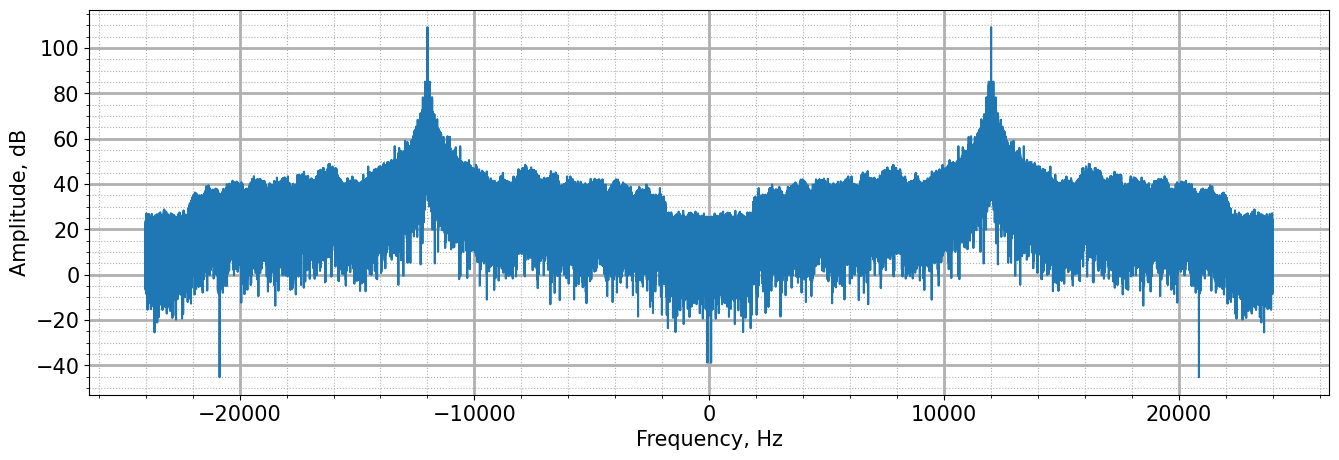

In [221]:
plotAmplFreqResp(pm_signal_recorded, Fs, True, True)

In [222]:
# Фильтруем зашумленный сигнал ДО демодуляции
pm_signal_clean = sg.lfilter(*bpf, pm_signal_recorded)

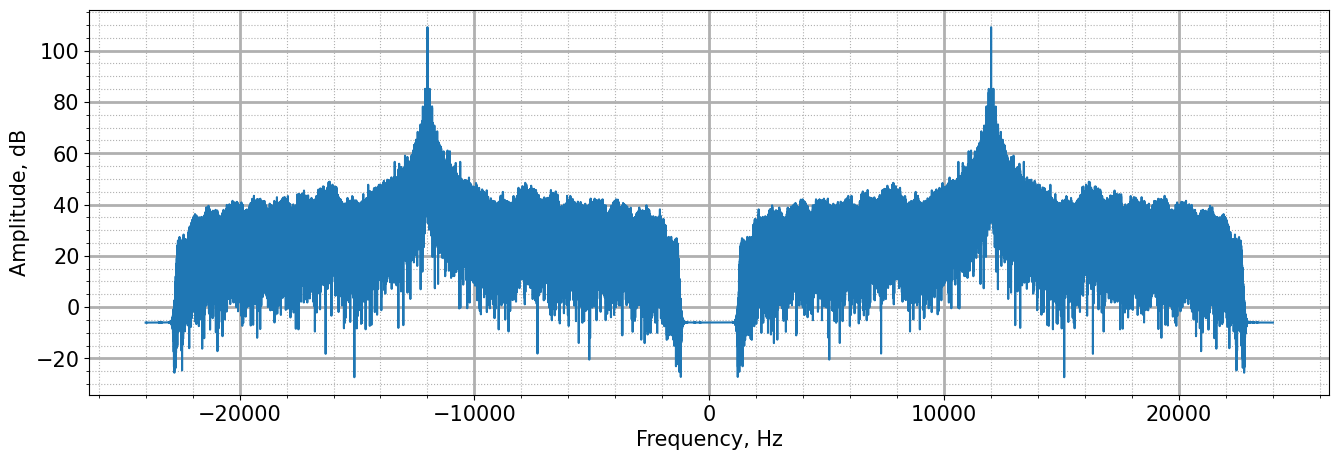

In [223]:
plotAmplFreqResp(pm_signal_clean, Fs, True, True)

Буду восстанавливать при помощи сдвига несущей + взятие угла у комплексной огибающей
В отличие от ЧМ, для ФМ нам не нужно брать производную от фазы. Сама фаза - это сигнал.

In [224]:
restored_signal_pm = pm_signal_clean * np.exp(-1j * 2 * np.pi * f_c_pm * t)

filtered_signal_pm = sg.lfilter(*lpf_baseband, restored_signal_pm)

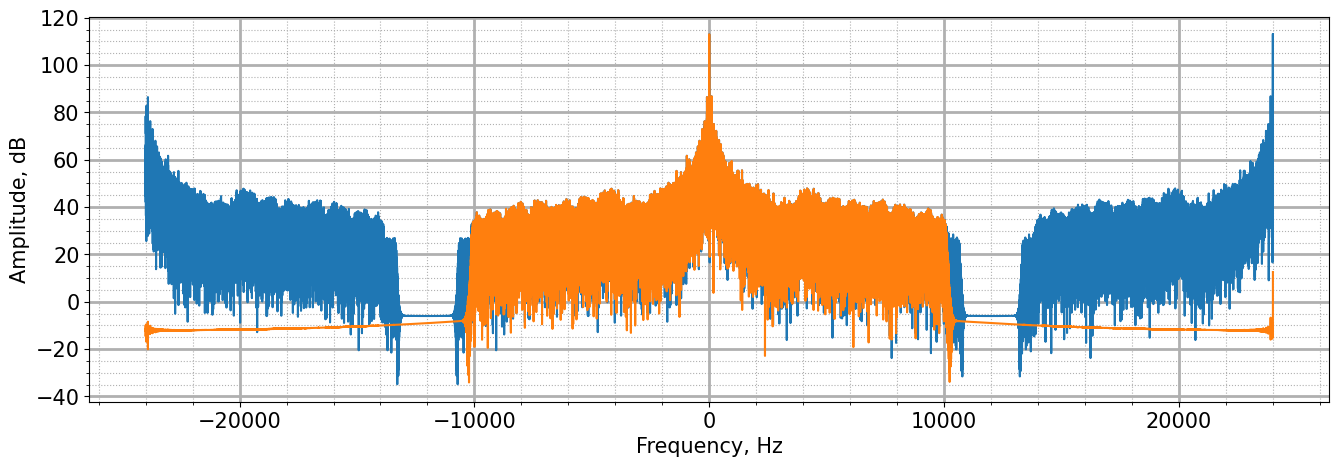

In [225]:
plotAmplFreqResp(restored_signal_pm, Fs, True)
plotAmplFreqResp(filtered_signal_pm, Fs, True)

In [226]:
# Для ФМ сама фаза является информационным сигналом (умноженным на индекс)
instantaneous_phase_pm = np.unwrap(np.angle(filtered_signal_pm))

result_filtered_signal_pm = instantaneous_phase_pm / m_idx_audio
result_filtered_signal_pm = result_filtered_signal_pm - np.mean(result_filtered_signal_pm)

# Прогоним еще раз через ФНЧ для идеальной гладкости
result_filtered_signal_pm = sg.lfilter(*lpf_baseband, result_filtered_signal_pm)

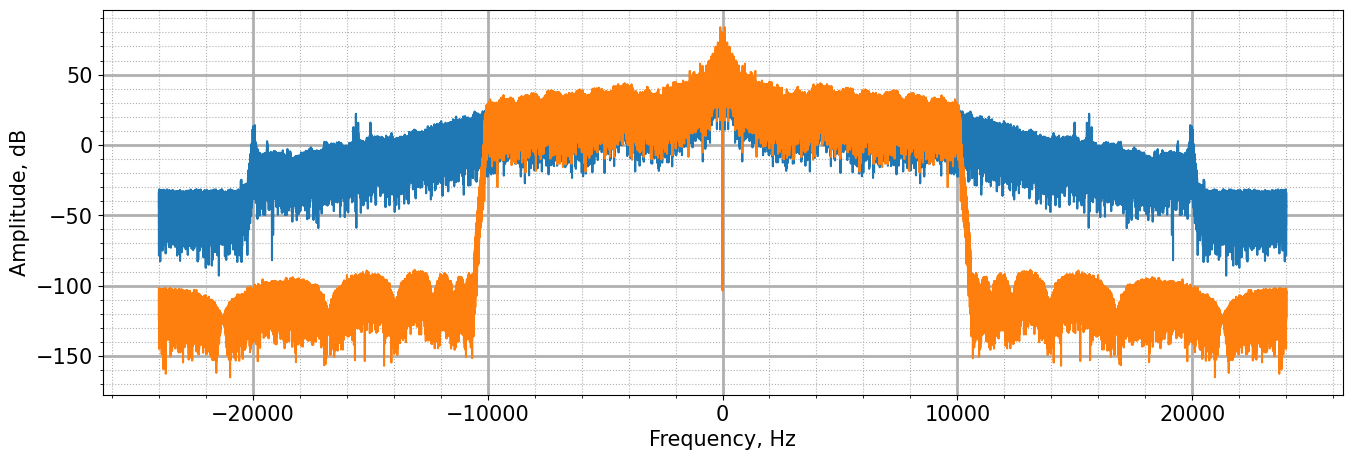

In [227]:
plotAmplFreqResp(info_signal, Fs, True)
plotAmplFreqResp(result_filtered_signal_pm, Fs, True)

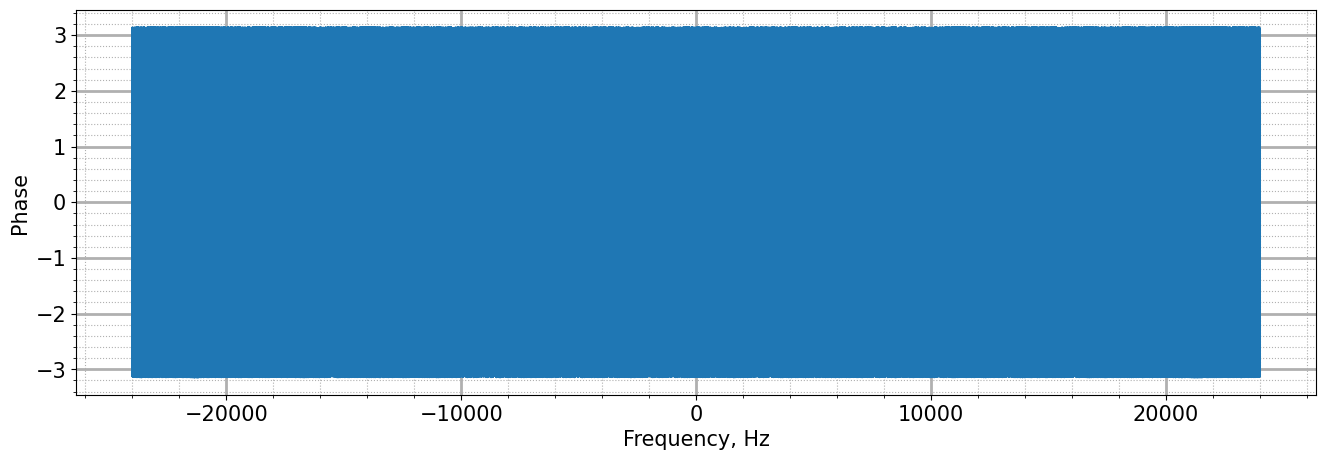

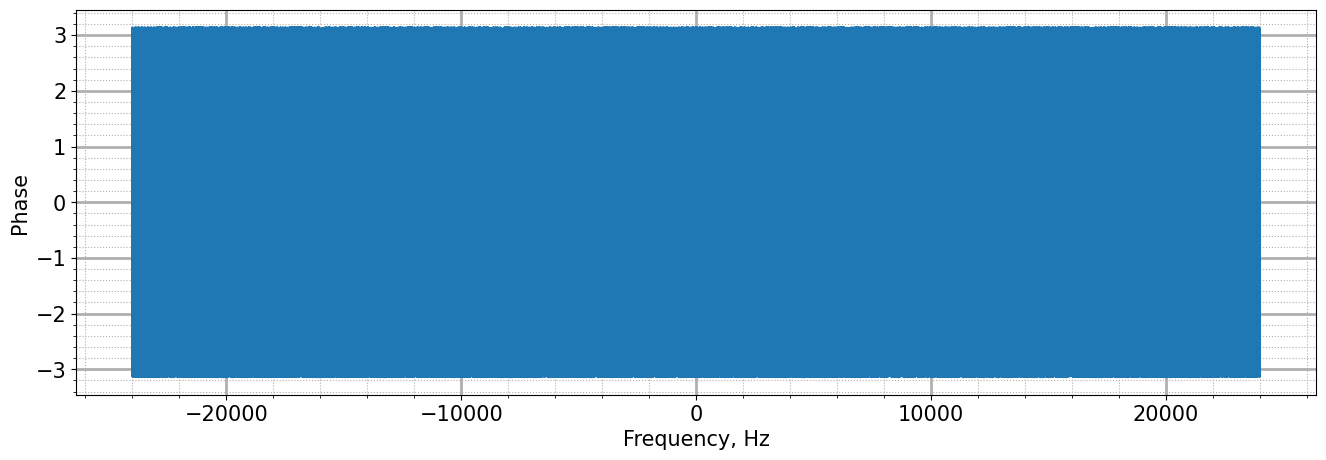

In [228]:
plotPhaseFreqResp(result_filtered_signal_pm, Fs)
plotPhaseFreqResp(info_signal, Fs)

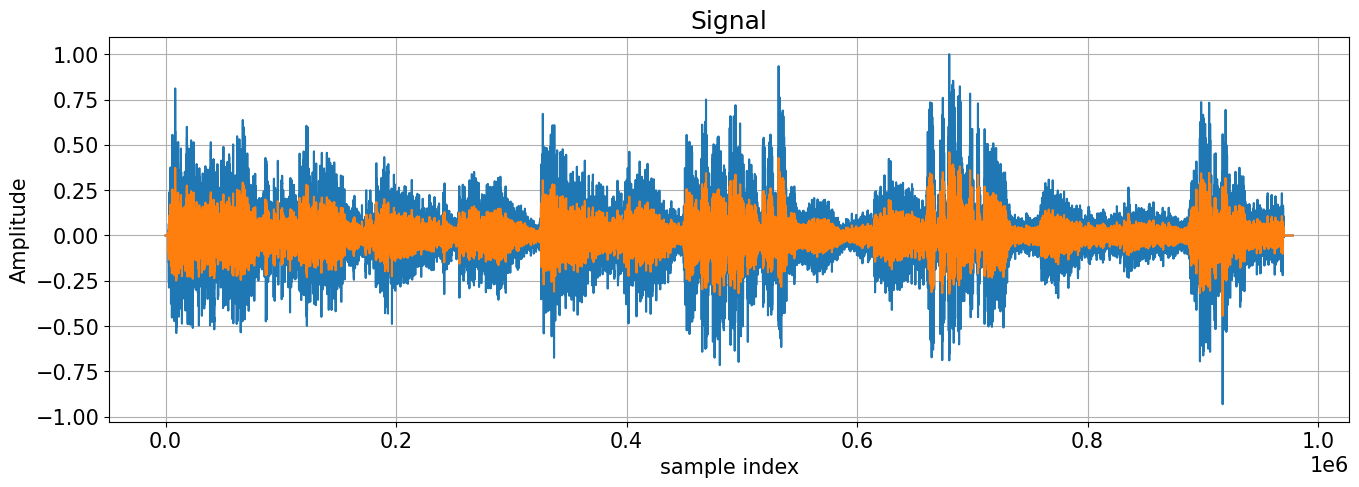

In [229]:
plotSignalTime(result_filtered_signal_pm)
plotSignalTime(info_signal)

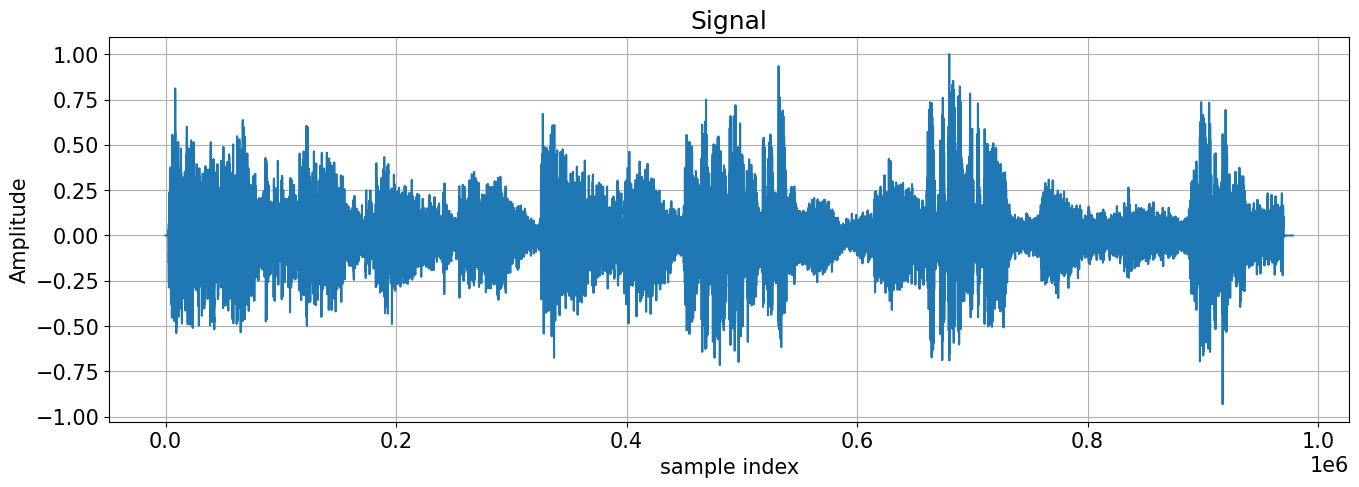

In [230]:
plotSignalTime(result_filtered_signal_pm)

In [231]:
norm_filtered_signal_pm = result_filtered_signal_pm / max(np.abs(result_filtered_signal_pm))
wavio.write("sounds/my_result_pm_T.wav", norm_filtered_signal_pm, Fs, sampwidth=2)

# Demodulate secret PM signal #

Создаем секретный ФМ сигнал по той же логике (реверс + нестандартная несущая)

In [232]:
Fs / 5

9600.0

In [233]:
f_c_secret_pm = Fs / 5
m_idx_secret = np.pi / 2

secret_pm_signal = modulatePM(secret_info, f_c_secret_pm, m_idx_secret, Fs, t_sec)

secret_pm_signal_noised = secret_pm_signal + np.random.normal(0, 0.001, len(secret_pm_signal))
sf.write("sounds/my_secret_pm.wav", secret_pm_signal_noised, Fs)

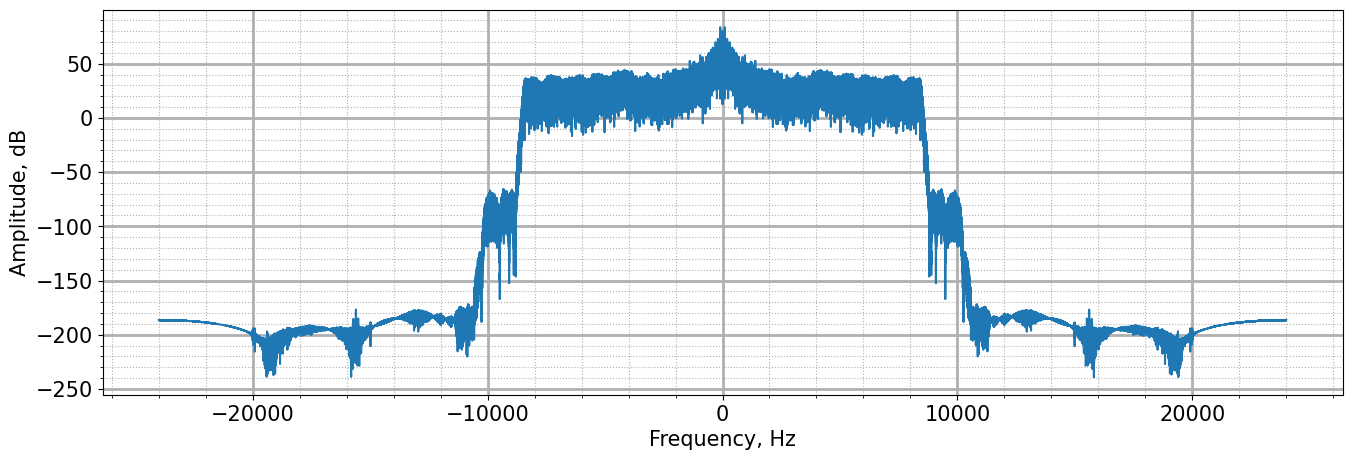

In [234]:
plotAmplFreqResp(secret_info, Fs, True)

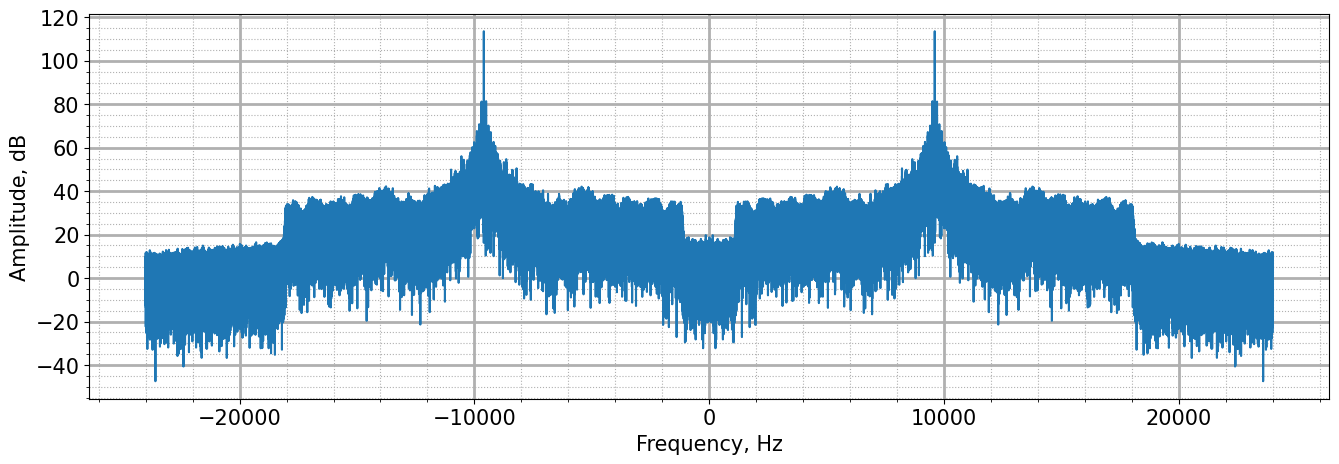

In [235]:
plotAmplFreqResp(secret_pm_signal_noised, Fs, True)

Демодуляция секретного ФМ сигнала

In [ ]:
pm_signal_recorded_sec, Fs = sf.read('sounds/my_secret_pm.wav')

fft_signal_pm_sec = np.fft.fft(pm_signal_recorded_sec)
fft_signal_pm_sec = np.fft.fftshift(fft_signal_pm_sec)

freqs_pm_sec = np.linspace(-Fs/2, Fs/2, len(fft_signal_pm_sec))
f_c_found_pm = np.abs(freqs_pm_sec[np.argmax(fft_signal_pm_sec)])

print("Found carrier frequency for PM:", f_c_found_pm)

Found carrier frequency for PM: 9600.009815710044


In [237]:
restored_secret_pm = pm_signal_recorded_sec * np.exp(-1j * 2 * np.pi * f_c_found_pm * t_sec)

filtered_secret_pm = sg.lfilter(*lpf_baseband_sec, restored_secret_pm)

result_secret_pm = np.unwrap(np.angle(filtered_secret_pm))

result_secret_pm = result_secret_pm - np.mean(result_secret_pm)

result_secret_pm = sg.lfilter(*lpf_baseband_sec, result_secret_pm)
norm_secret_pm = result_secret_pm / max(np.abs(result_secret_pm))

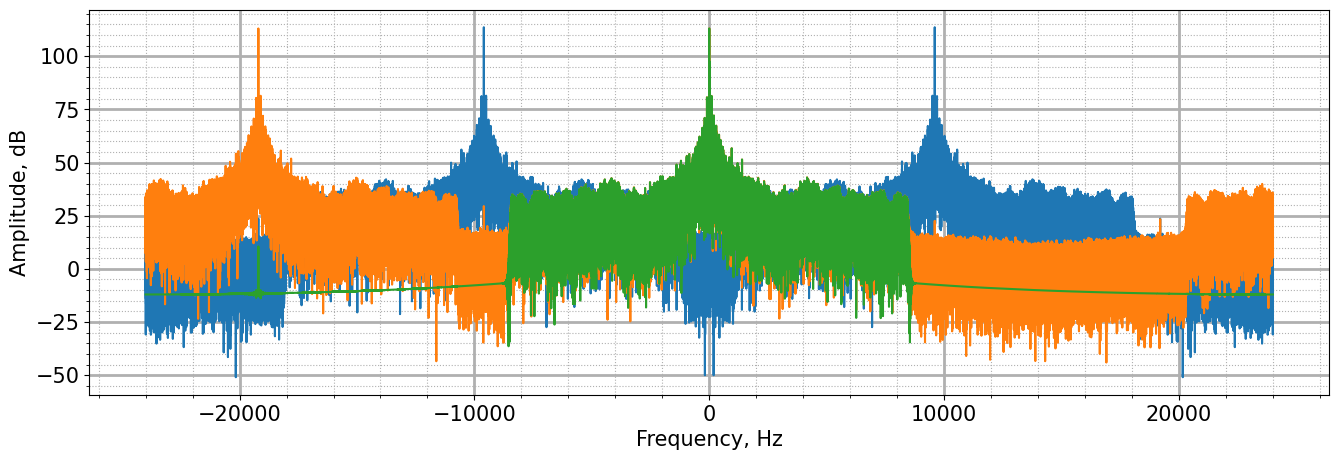

In [238]:
plotAmplFreqResp(pm_signal_recorded_sec, Fs, True)
plotAmplFreqResp(restored_secret_pm, Fs, True)
plotAmplFreqResp(filtered_secret_pm, Fs, True)

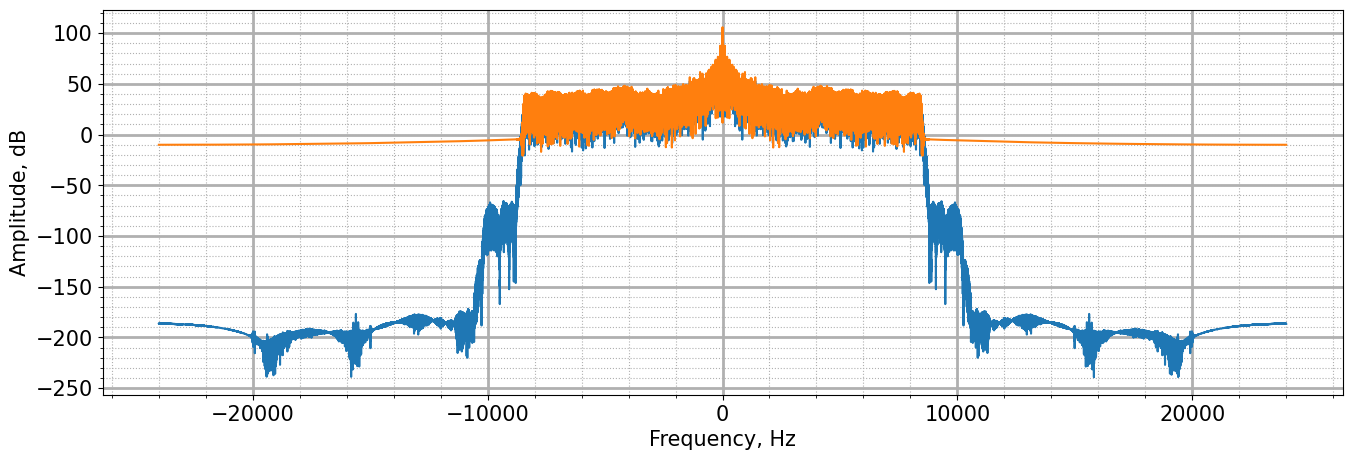

In [239]:
plotAmplFreqResp(secret_info, Fs, True)
plotAmplFreqResp(result_secret_pm, Fs, True)

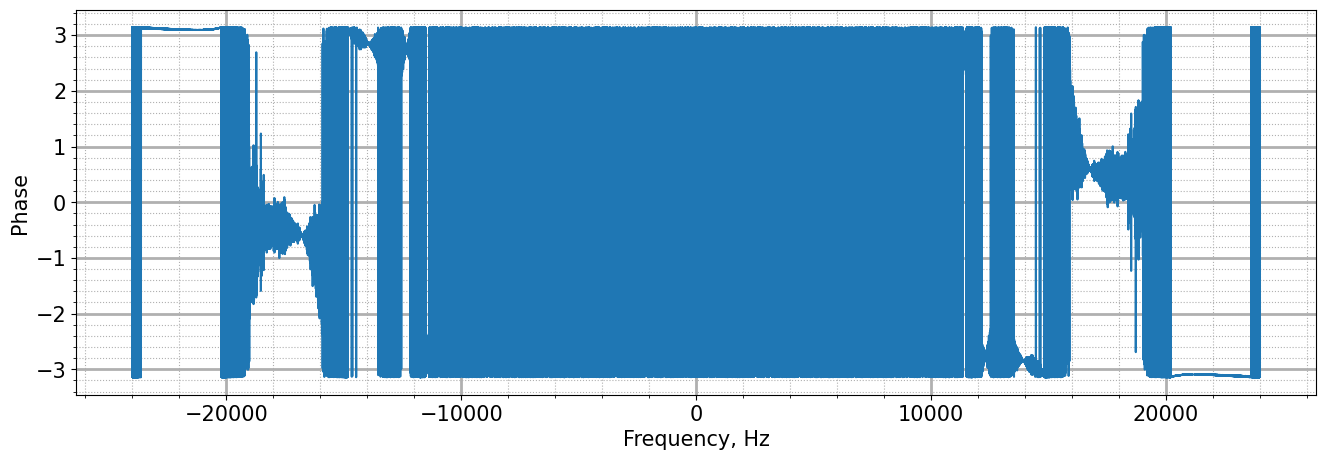

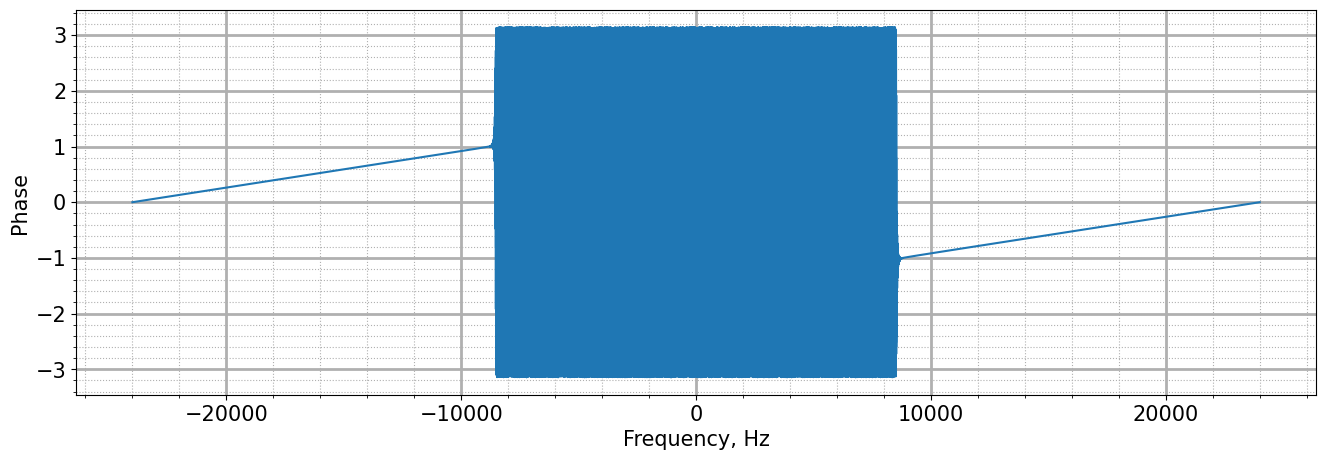

In [240]:
plotPhaseFreqResp(secret_info, Fs)
plotPhaseFreqResp(result_secret_pm, Fs)

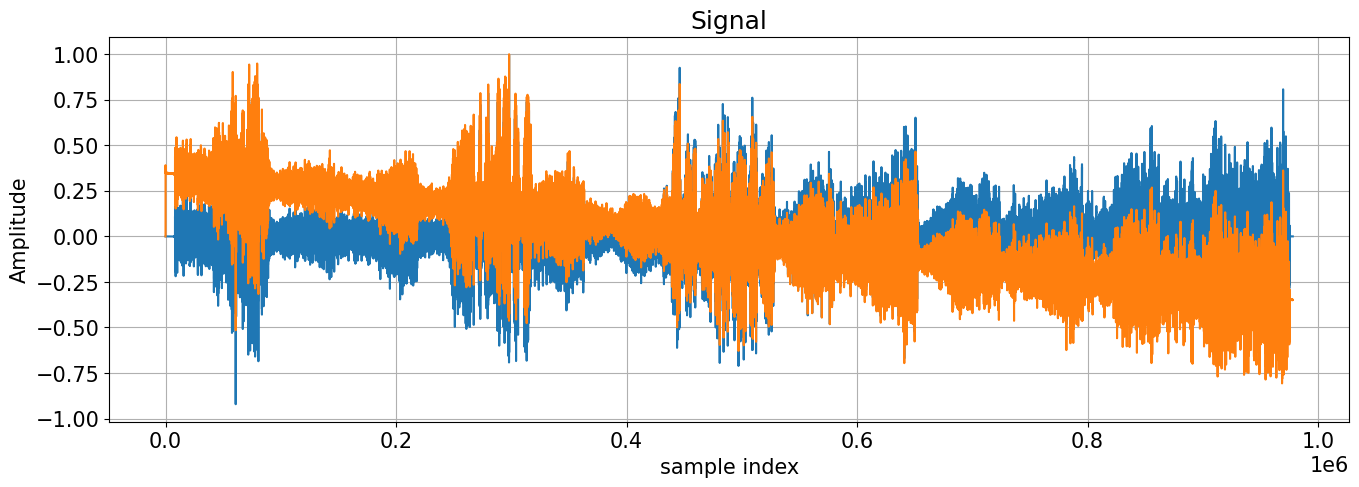

In [241]:
plotSignalTime(secret_info)
plotSignalTime(norm_secret_pm)

КРАЙНЕ ИНТЕРЕСНОЕ ЗАМЕЧАНИЕ!!! Заметен линейный тренд (спад) у принятого и демодулированного сигнала. 2 дня пытался найти, в чем дело, оказывается, столь сильным оказывается влияние разницы в частотах несущей сигнала и гетеродина. В предыдущем примере мы знали частоту точно, поэтому этой проблемы не было. А тут есть. Но на звук никак не влияет глобально, судя по моим ощущениям

In [243]:
# Разворачиваем обратно
wavio.write("sounds/my_secret_pm_solved.wav", norm_secret_pm, Fs, sampwidth=2)

# FM сигнал Акрама

In [7]:
fm_signal_recorded_sec, Fs = sf.read('sounds/fm_secret_Akram.wav')

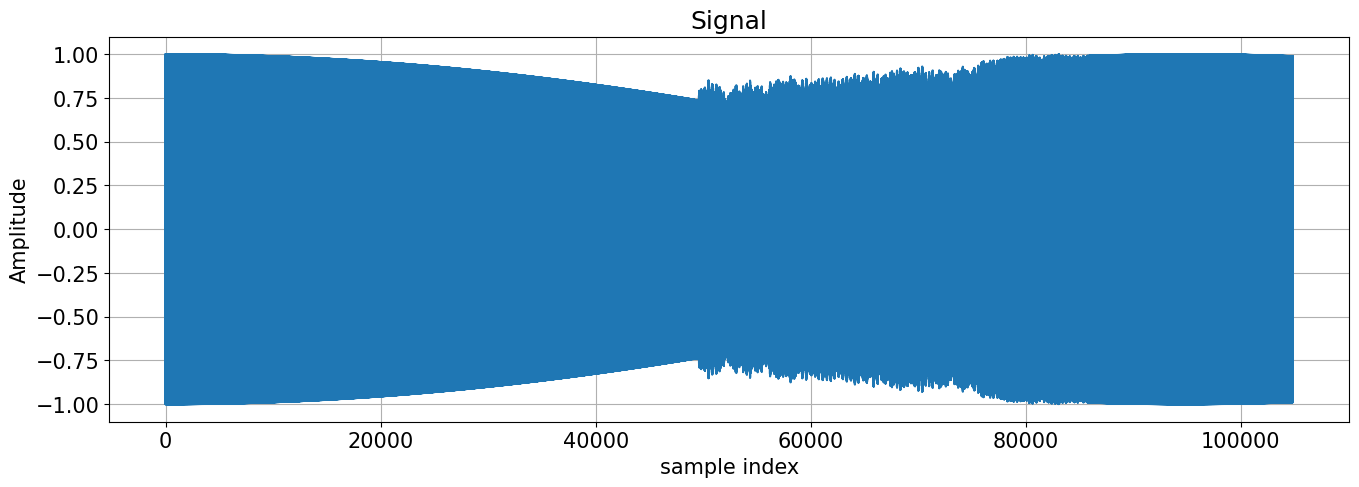

In [9]:
plotSignalTime(fm_signal_recorded_sec)

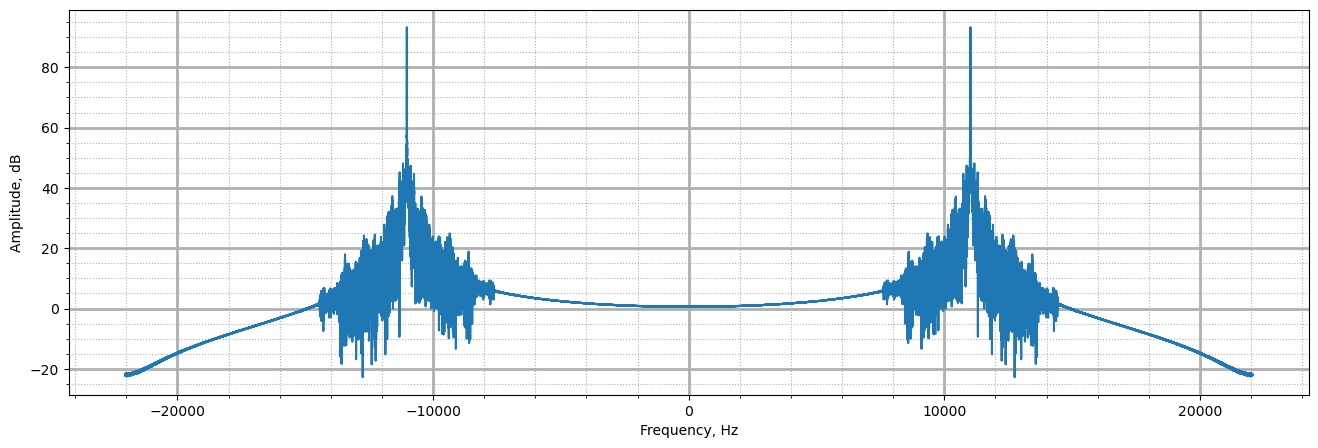

In [8]:
plotAmplFreqResp(fm_signal_recorded_sec, Fs, use_log_scale=True)

Надо понять частоту несущей. В спектре находим пик (на какой частоте), используем argmax

In [10]:
fft_signal_sec = np.fft.fft(fm_signal_recorded_sec) 
fft_signal_sec = np.fft.fftshift(fft_signal_sec) 

freqs_sec = np.linspace(-Fs/2, Fs/2, len(fft_signal_sec))

f_c_found = np.abs(freqs_sec[np.argmax(fft_signal_sec)])

print(f_c_found)

11025.315507817344


In [13]:
fm_signal_clean_sec = fm_signal_recorded_sec

Буду восстанавливать при помощи сдвига несущей + взятие угла у комплексной огибающей

In [15]:
t_sec = np.linspace(0, len(fm_signal_recorded_sec) / Fs, len(fm_signal_recorded_sec))

In [16]:
t_sec

array([0.00000000e+00, 2.26759533e-05, 4.53519065e-05, ...,
       2.37709751e+00, 2.37712018e+00, 2.37714286e+00], shape=(104832,))

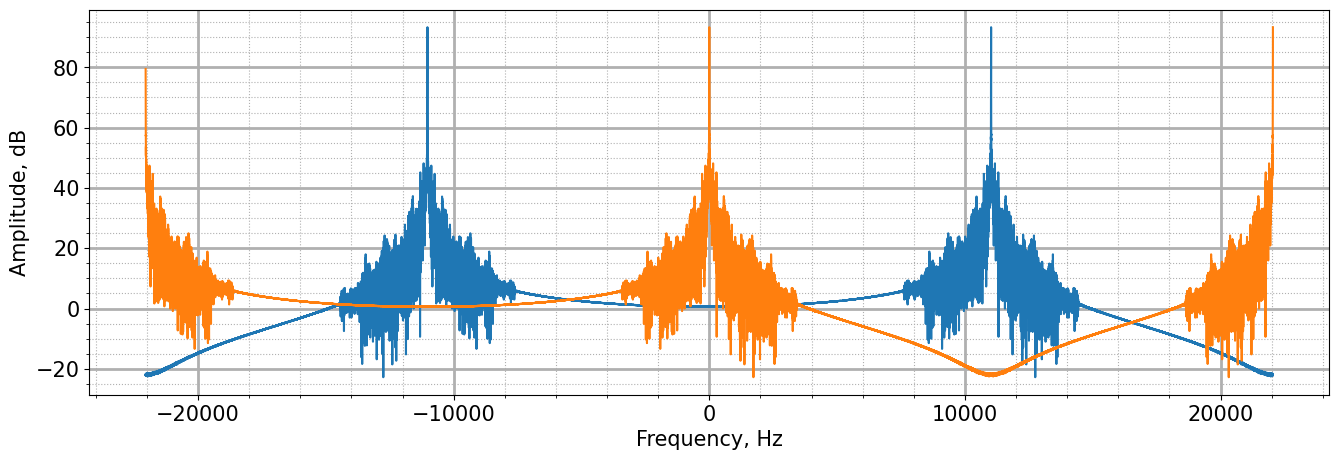

In [18]:
plotAmplFreqResp(fm_signal_clean_sec, Fs, True)
plotAmplFreqResp(restored_signal_sec, Fs, True)

In [19]:
restored_signal_sec = fm_signal_clean_sec * np.exp(-1j * 2 * np.pi * f_c_found * t_sec)

lpf_baseband_sec = sg.iirdesign(4500, 5000, 0.001, 100, fs=Fs)

filtered_signal_sec = sg.lfilter(*lpf_baseband_sec, restored_signal_sec)

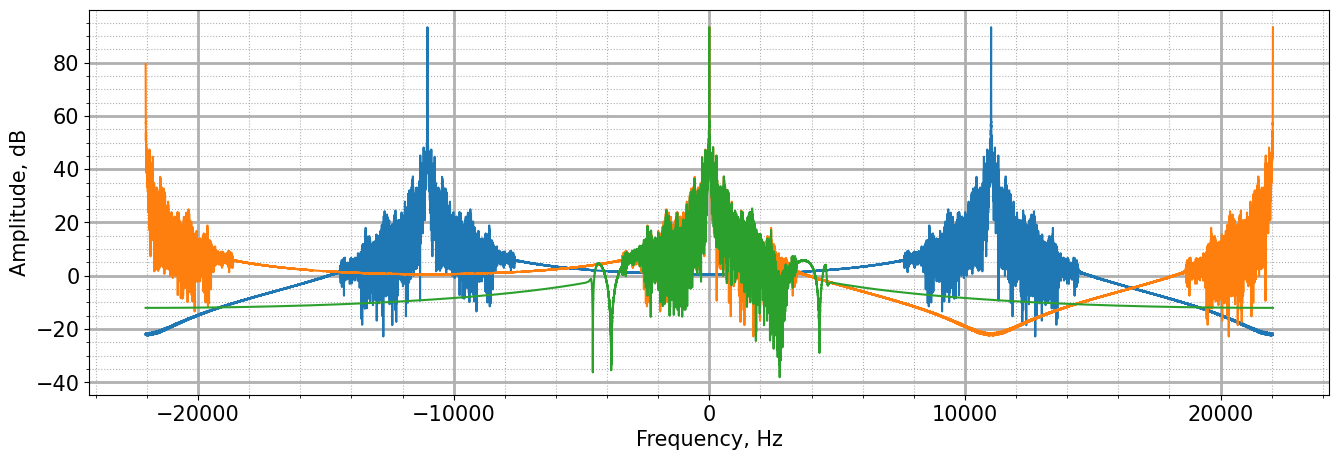

In [20]:
plotAmplFreqResp(fm_signal_clean_sec, Fs, True)
plotAmplFreqResp(restored_signal_sec, Fs, True)
plotAmplFreqResp(filtered_signal_sec, Fs, True)

In [24]:
instantaneous_phase_sec = np.unwrap(np.angle(filtered_signal_sec))

instantaneous_frequency_sec = np.diff(instantaneous_phase_sec) * Fs / (2.0 * np.pi)
instantaneous_frequency_sec = np.append(instantaneous_frequency_sec, instantaneous_frequency_sec[-1])  # Возвращаем размер массива до прежнего, дублируя последний элемент

result_filtered_signal_sec = instantaneous_frequency_sec - np.mean(instantaneous_frequency_sec)

# Прогоним еще раз через ФНЧ для идеальной гладкости
result_filtered_signal_sec = sg.lfilter(*lpf_baseband_sec, result_filtered_signal_sec)

norm_filtered_signal_sec = result_filtered_signal_sec/max(np.abs(result_filtered_signal_sec))

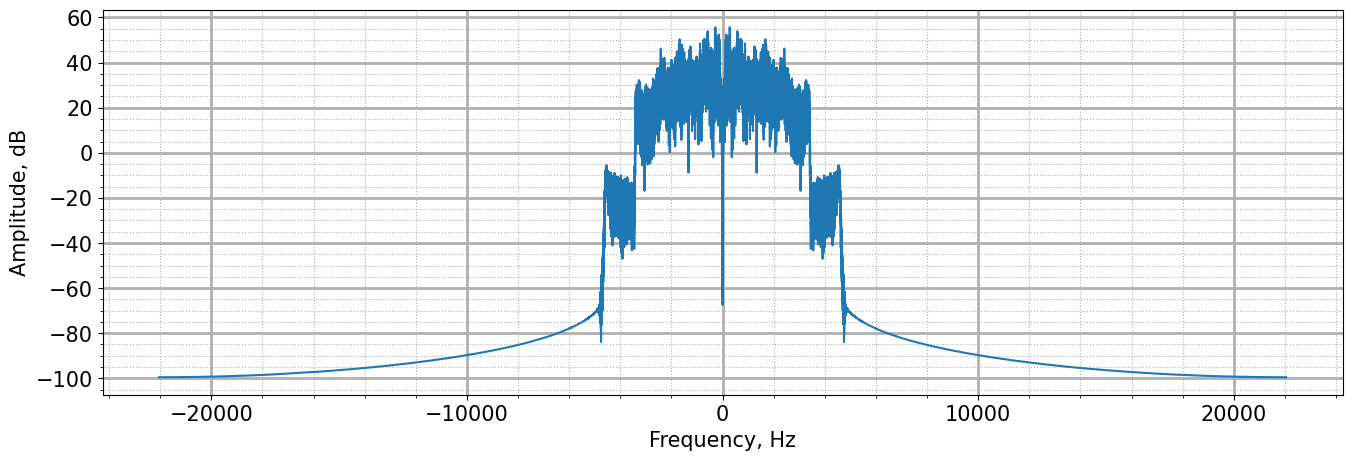

In [26]:
plotAmplFreqResp(norm_filtered_signal_sec, Fs, True)

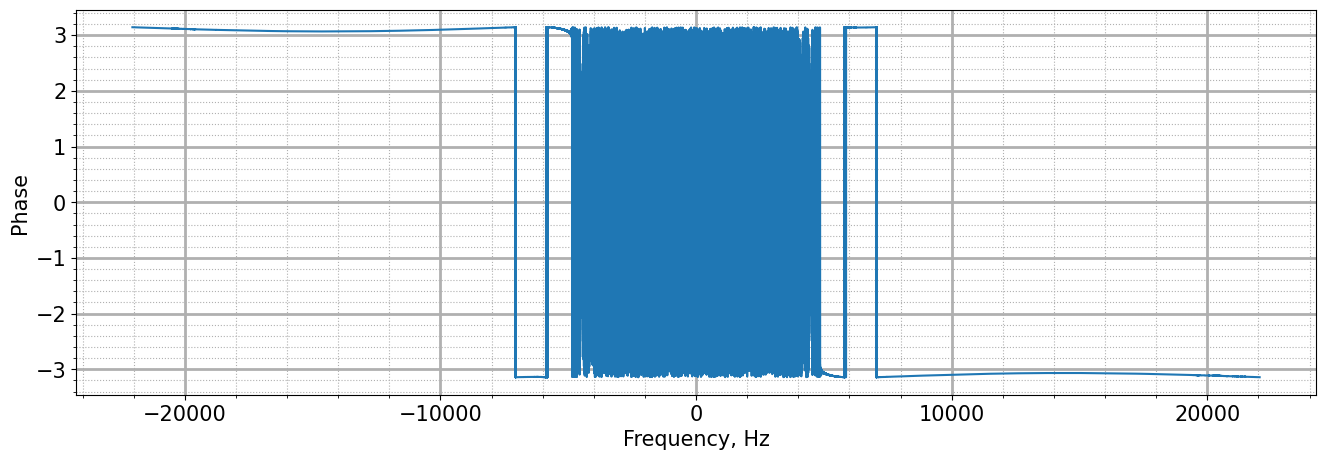

In [28]:
# plotPhaseFreqResp(secret_info, Fs)
plotPhaseFreqResp(norm_filtered_signal_sec, Fs)

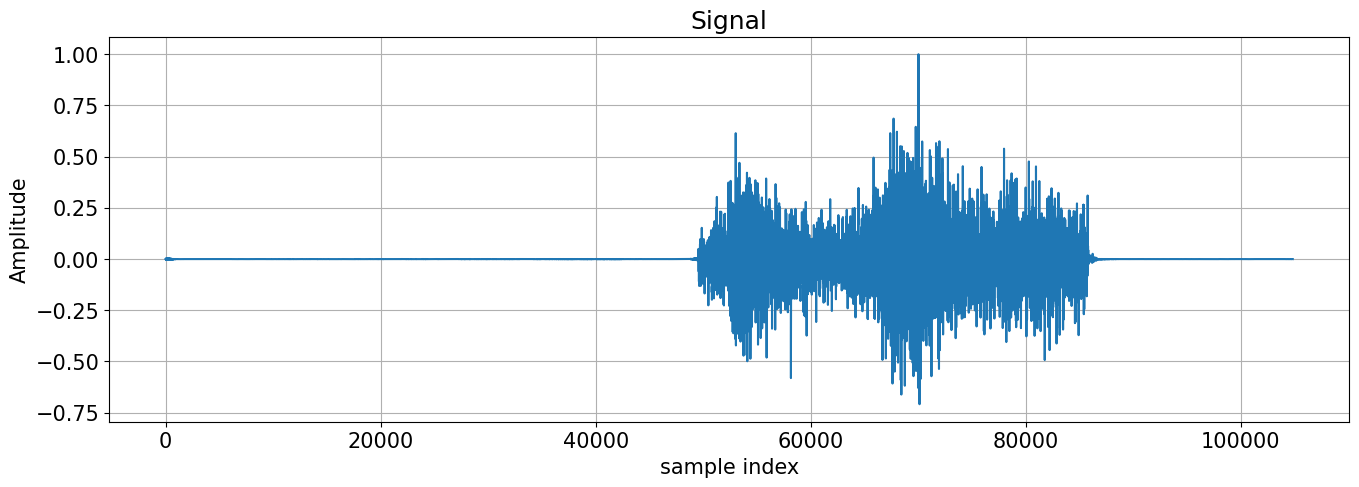

In [29]:
plotSignalTime(norm_filtered_signal_sec)
# plotSignalTime(secret_info)

In [30]:
wavio.write("sounds/Akram_fm_secret_solved.wav", norm_filtered_signal_sec, Fs, sampwidth=2)